# Bank Churners — BI Reporting

**Objective:** Produce BI-ready tables, figures, and an executive summary for Power BI and business stakeholders.

**Inputs:** Raw customer file, saved LightGBM pipeline from modeling.

**Outputs:** `reports/tables/` (including `power_bi_master.csv`), `reports/figures/`, `reports/executive_summary.md`.

**Important:** Descriptive churn rates come from historical `Attrition_Flag`. Model scores are predictive and used for prioritization only.


## 1. Setup


In [1]:
from __future__ import annotations

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

sns.set_theme(style="whitegrid", context="talk")

ROOT = Path.cwd()
if not (ROOT / "data" / "raw" / "BankChurners.csv").exists():
    ROOT = ROOT.parent
if not (ROOT / "data" / "raw" / "BankChurners.csv").exists():
    raise FileNotFoundError("Expected data/raw/BankChurners.csv")

RAW_PATH = ROOT / "data" / "raw" / "BankChurners.csv"
MODEL_PATH = ROOT / "artifacts" / "models" / "churn_model_pipeline.joblib"
METRICS_PATH = ROOT / "reports" / "tables" / "modeling_final_metrics.csv"
SELECTION_PATH = ROOT / "reports" / "tables" / "modeling_final_selection.csv"
FIG_DIR = ROOT / "reports" / "figures"
TABLE_DIR = ROOT / "reports" / "tables"
SUMMARY_PATH = ROOT / "reports" / "executive_summary.md"

for directory in [FIG_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

LEAKAGE_COLS = [
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2",
]

NUMERIC_FEATURES = [
    "Customer_Age", "Dependent_count", "Credit_Limit", "Total_Revolving_Bal",
    "Avg_Open_To_Buy", "Months_on_book", "Total_Relationship_Count",
    "Months_Inactive_12_mon", "Contacts_Count_12_mon", "Total_Trans_Amt",
    "Total_Trans_Ct", "Total_Amt_Chng_Q4_Q1", "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio",
]
CATEGORICAL_FEATURES = [
    "Gender", "Education_Level", "Marital_Status", "Income_Category", "Card_Category",
]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
SEGMENT_DIMENSIONS = [
    ("card_category", "Card_Category"),
    ("income_category", "Income_Category"),
    ("age_band", "age_band"),
    ("tenure_band", "tenure_band"),
    ("inactivity_band", "inactivity_band"),
]
LOW_RISK_MAX = 0.30

print(f"Repository root: {ROOT}")


Repository root: C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp


## 2. Segmentation Helpers


In [2]:
def make_age_band(age: pd.Series) -> pd.Series:
    return pd.cut(
        age,
        bins=[0, 34, 49, 64, 200],
        labels=["Under 35", "35-49", "50-64", "65+"],
        right=True,
    ).astype(str)


def make_tenure_band(months: pd.Series) -> pd.Series:
    return pd.cut(
        months,
        bins=[-1, 24, 48, 72, 500],
        labels=["0-24 mo", "25-48 mo", "49-72 mo", "73+ mo"],
        right=True,
    ).astype(str)


def make_inactivity_band(months: pd.Series) -> pd.Series:
    return pd.cut(
        months,
        bins=[-1, 1, 3, 6, 100],
        labels=["0-1 mo", "2-3 mo", "4-6 mo", "6+ mo"],
        right=True,
    ).astype(str)


def assign_risk_band(prob: pd.Series, threshold: float) -> pd.Series:
    return np.select(
        [prob < LOW_RISK_MAX, prob < threshold, prob >= threshold],
        ["Low", "Medium", "High"],
        default="Medium",
    )


def segment_summary(df: pd.DataFrame, dimension: str, value_col: str) -> pd.DataFrame:
    grouped = (
        df.groupby(value_col, dropna=False)
        .agg(
            customer_count=("CLIENTNUM", "count"),
            attrited_count=("observed_churn", "sum"),
            observed_churn_rate=("observed_churn", "mean"),
            avg_churn_probability=("churn_probability", "mean"),
            predicted_high_risk_count=("is_high_risk", "sum"),
        )
        .reset_index()
    )
    grouped.insert(0, "segment_dimension", dimension)
    grouped = grouped.rename(columns={value_col: "segment_value"})
    grouped["observed_churn_rate_pct"] = (grouped["observed_churn_rate"] * 100).round(2)
    grouped["avg_churn_probability_pct"] = (grouped["avg_churn_probability"] * 100).round(2)
    return grouped


## 3. Load Data, Score Portfolio, Build Master Table


In [3]:
raw = pd.read_csv(RAW_PATH)
raw = raw.drop(columns=[c for c in LEAKAGE_COLS if c in raw.columns])
raw["observed_churn"] = (raw["Attrition_Flag"] == "Attrited Customer").astype(int)

model_artifact = joblib.load(MODEL_PATH)
if isinstance(model_artifact, dict):
    pipeline = model_artifact["pipeline"]
    threshold = float(model_artifact.get("threshold", 0.50))
    metadata = model_artifact.get("metadata", {})
    model_name = metadata.get("model_name", "lightgbm")
    feature_cols = metadata.get("feature_columns", FEATURES)
else:
    pipeline = model_artifact
    threshold = 0.50
    metadata = {}
    model_name = "lightgbm"
    feature_cols = FEATURES

if METRICS_PATH.exists():
    metrics_df = pd.read_csv(METRICS_PATH)
    test_metrics = metrics_df[metrics_df["split"] == "test"].iloc[0]
    threshold = float(test_metrics["threshold"])
else:
    test_metrics = None

if SELECTION_PATH.exists():
    model_name = pd.read_csv(SELECTION_PATH).iloc[0]["final_model"]

X = raw[feature_cols]
churn_probability = pipeline.predict_proba(X)[:, 1]
predicted_churn = (churn_probability >= threshold).astype(int)
is_high_risk = predicted_churn.astype(bool)

master = raw.copy()
master["churn_probability"] = churn_probability
master["predicted_churn"] = predicted_churn
master["is_high_risk"] = is_high_risk
master["age_band"] = make_age_band(master["Customer_Age"])
master["tenure_band"] = make_tenure_band(master["Months_on_book"])
master["inactivity_band"] = make_inactivity_band(master["Months_Inactive_12_mon"])
master["risk_band"] = assign_risk_band(master["churn_probability"], threshold)
master["decision_threshold_used"] = threshold
master["model_name"] = model_name

power_bi_cols = [
    "CLIENTNUM", "Attrition_Flag", "observed_churn", "churn_probability",
    "predicted_churn", "is_high_risk", "risk_band",
    "Gender", "Education_Level", "Marital_Status", "Income_Category", "Card_Category",
    "age_band", "tenure_band", "inactivity_band",
    "Customer_Age", "Dependent_count", "Months_on_book", "Months_Inactive_12_mon",
    "Contacts_Count_12_mon", "Credit_Limit", "Total_Revolving_Bal", "Avg_Open_To_Buy",
    "Total_Trans_Amt", "Total_Trans_Ct", "Total_Amt_Chng_Q4_Q1", "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio", "Total_Relationship_Count",
    "decision_threshold_used", "model_name",
]
power_bi = master[power_bi_cols].sort_values("churn_probability", ascending=False)
power_bi.to_csv(TABLE_DIR / "power_bi_master.csv", index=False)

print(f"Scored {len(power_bi):,} customers | threshold={threshold:.2f} | high-risk={int(is_high_risk.sum()):,}")
display(power_bi.head())


Scored 10,127 customers | threshold=0.50 | high-risk=1,594


,CLIENTNUM,Attrition_Flag,observed_churn,churn_probability,predicted_churn,is_high_risk,risk_band,Gender,Education_Level,Marital_Status,...,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Trans_Amt,Total_Trans_Ct,Total_Amt_Chng_Q4_Q1,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Total_Relationship_Count,decision_threshold_used,model_name
9602,715645908,Attrited Customer,1,0.999984,1,True,High,M,High School,Single,...,0,34516.0,8480,71,0.969,0.821,0.0,5,0.5,lightgbm
8379,779183958,Attrited Customer,1,0.999982,1,True,High,F,Graduate,Single,...,0,1492.0,2469,38,0.502,0.267,0.0,1,0.5,lightgbm
10018,709566408,Attrited Customer,1,0.999981,1,True,High,F,Graduate,Single,...,0,4458.0,9640,70,0.935,0.707,0.0,5,0.5,lightgbm
564,752604633,Attrited Customer,1,0.999976,1,True,High,M,College,Married,...,0,6462.0,761,17,0.856,0.214,0.0,2,0.5,lightgbm
6244,718653333,Attrited Customer,1,0.999973,1,True,High,F,College,Single,...,0,1833.0,2037,31,0.549,0.292,0.0,1,0.5,lightgbm


## 4. KPI And Segment Tables


In [4]:
total_customers = len(master)
attrited = int(master["observed_churn"].sum())
observed_rate = attrited / total_customers * 100
high_risk_count = int(is_high_risk.sum())
high_risk_rate = high_risk_count / total_customers * 100
avg_prob = master["churn_probability"].mean() * 100

churn_rate_summary = pd.DataFrame([
    {"metric": "total_customers", "value": total_customers, "notes": "Full portfolio in raw file"},
    {"metric": "observed_attrited_customers", "value": attrited, "notes": "Attrition_Flag = Attrited Customer"},
    {"metric": "observed_churn_rate_pct", "value": round(observed_rate, 2), "notes": "Descriptive historical churn rate"},
    {"metric": "avg_model_churn_probability_pct", "value": round(avg_prob, 2), "notes": "Mean predicted churn probability (model-based)"},
    {"metric": "high_risk_customers_model", "value": high_risk_count, "notes": f"Predicted churn at probability >= {threshold:.3f}"},
    {"metric": "high_risk_rate_pct", "value": round(high_risk_rate, 2), "notes": "Share of portfolio flagged for follow-up"},
])
churn_rate_summary.to_csv(TABLE_DIR / "churn_rate_summary.csv", index=False)

segment_tables = [segment_summary(master, dim, col) for dim, col in SEGMENT_DIMENSIONS]
churn_by_segment = pd.concat(segment_tables, ignore_index=True)
churn_by_segment.to_csv(TABLE_DIR / "churn_by_segment.csv", index=False)

high_risk_cols = [
    "CLIENTNUM", "churn_probability", "predicted_churn",
    "Card_Category", "Income_Category", "age_band", "tenure_band", "inactivity_band",
    "Months_on_book", "Months_Inactive_12_mon", "Total_Trans_Ct", "Contacts_Count_12_mon",
]
high_risk = master.loc[is_high_risk, high_risk_cols].copy()
high_risk = high_risk.rename(columns={
    "churn_probability": "churn_probability_score",
    "predicted_churn": "predicted_churn_class",
})
high_risk.insert(0, "high_risk_threshold_used", threshold)
high_risk = high_risk.sort_values("churn_probability_score", ascending=False)
high_risk.to_csv(TABLE_DIR / "high_risk_customers.csv", index=False)

if test_metrics is not None:
    model_metrics_summary = pd.DataFrame([{
        "model_name": model_name,
        "split": "test",
        "roc_auc": test_metrics["roc_auc"],
        "precision_churn_class": test_metrics["precision"],
        "recall_churn_class": test_metrics["recall"],
        "f1_churn_class": test_metrics["f1"],
        "accuracy": test_metrics["accuracy"],
        "threshold": threshold,
    }])
    model_metrics_summary.to_csv(TABLE_DIR / "model_metrics_summary.csv", index=False)

display(churn_rate_summary)
display(churn_by_segment.head(8))


,metric,value,notes
0,total_customers,10127.00,Full portfolio in raw file
1,observed_attrited_customers,1627.00,Attrition_Flag = Attrited Customer
2,observed_churn_rate_pct,16.07,Descriptive historical churn rate
3,avg_model_churn_probability_pct,15.82,Mean predicted churn probability (model-based)
4,high_risk_customers_model,1594.00,Predicted churn at probability >= 0.500
5,high_risk_rate_pct,15.74,Share of portfolio flagged for follow-up


,segment_dimension,segment_value,customer_count,attrited_count,observed_churn_rate,avg_churn_probability,predicted_high_risk_count,observed_churn_rate_pct,avg_churn_probability_pct
0,card_category,Blue,9436,1519,0.160979,0.158370,1486,16.10,15.84
1,card_category,Gold,116,21,0.181034,0.189100,22,18.10,18.91
2,card_category,Platinum,20,5,0.250000,0.249590,5,25.00,24.96
3,card_category,Silver,555,82,0.147748,0.146129,81,14.77,14.61
4,income_category,$120K +,727,126,0.173315,0.170373,124,17.33,17.04
5,income_category,$40K - $60K,1790,271,0.151397,0.147902,262,15.14,14.79
6,income_category,$60K - $80K,1402,189,0.134807,0.130060,179,13.48,13.01
7,income_category,$80K - $120K,1535,242,0.157655,0.153765,234,15.77,15.38


## 5. Power BI-Style Dashboard Figures

Reproduce en Python (matplotlib + seaborn) las visualizaciones sugeridas para Power BI:

| Página | Archivos generados |
|--------|-------------------|
| **1 — Executive overview** | `pbi_dashboard_page1.png`, `churn_overview.png` |
| **2 — Segment analysis** | `pbi_dashboard_page2.png`, `churn_by_segment.png` |
| **3 — High-risk operations** | `pbi_dashboard_page3.png`, `churn_model_risk_distribution.png` |
| **4 — Behavior signals** | `pbi_dashboard_page4.png` |

**Convención de color:** azul = observado (histórico) · naranja = predictivo (modelo)


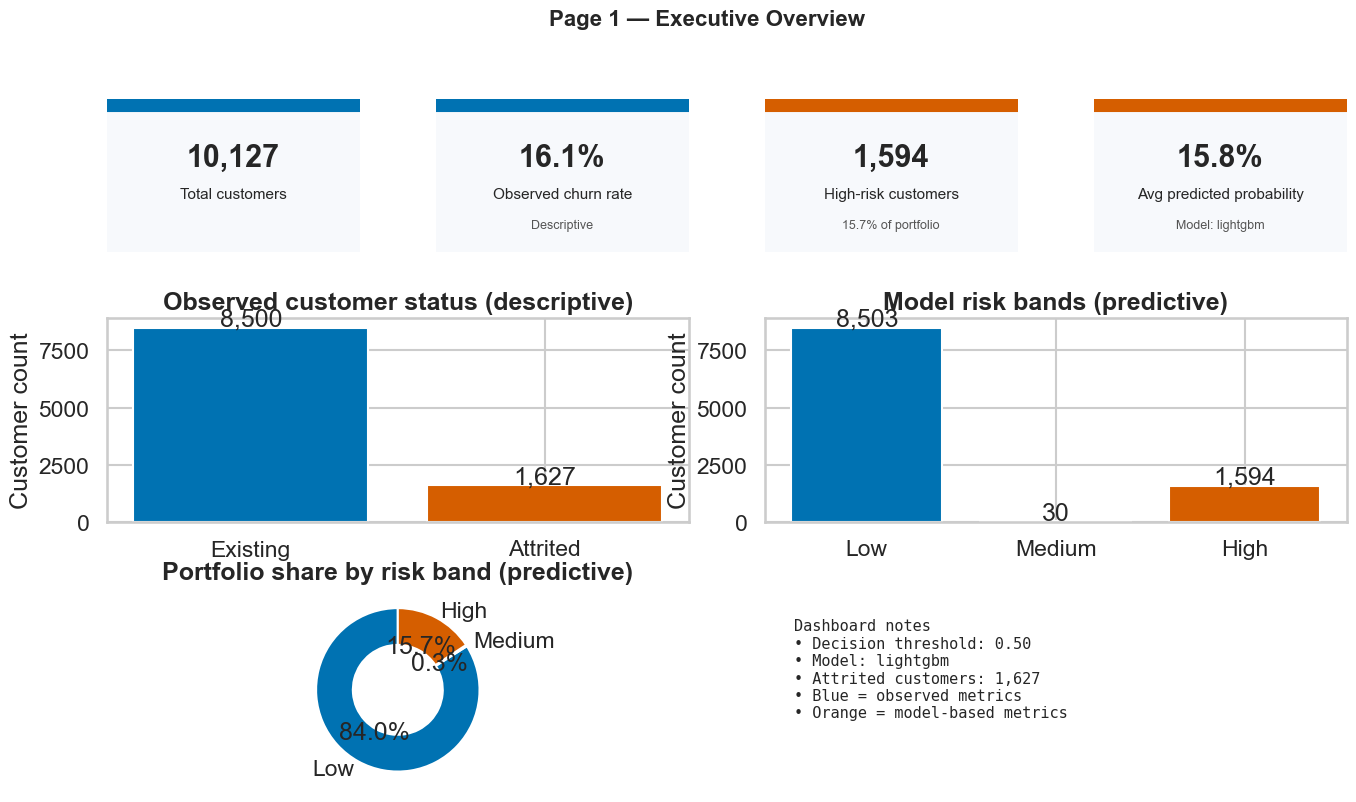

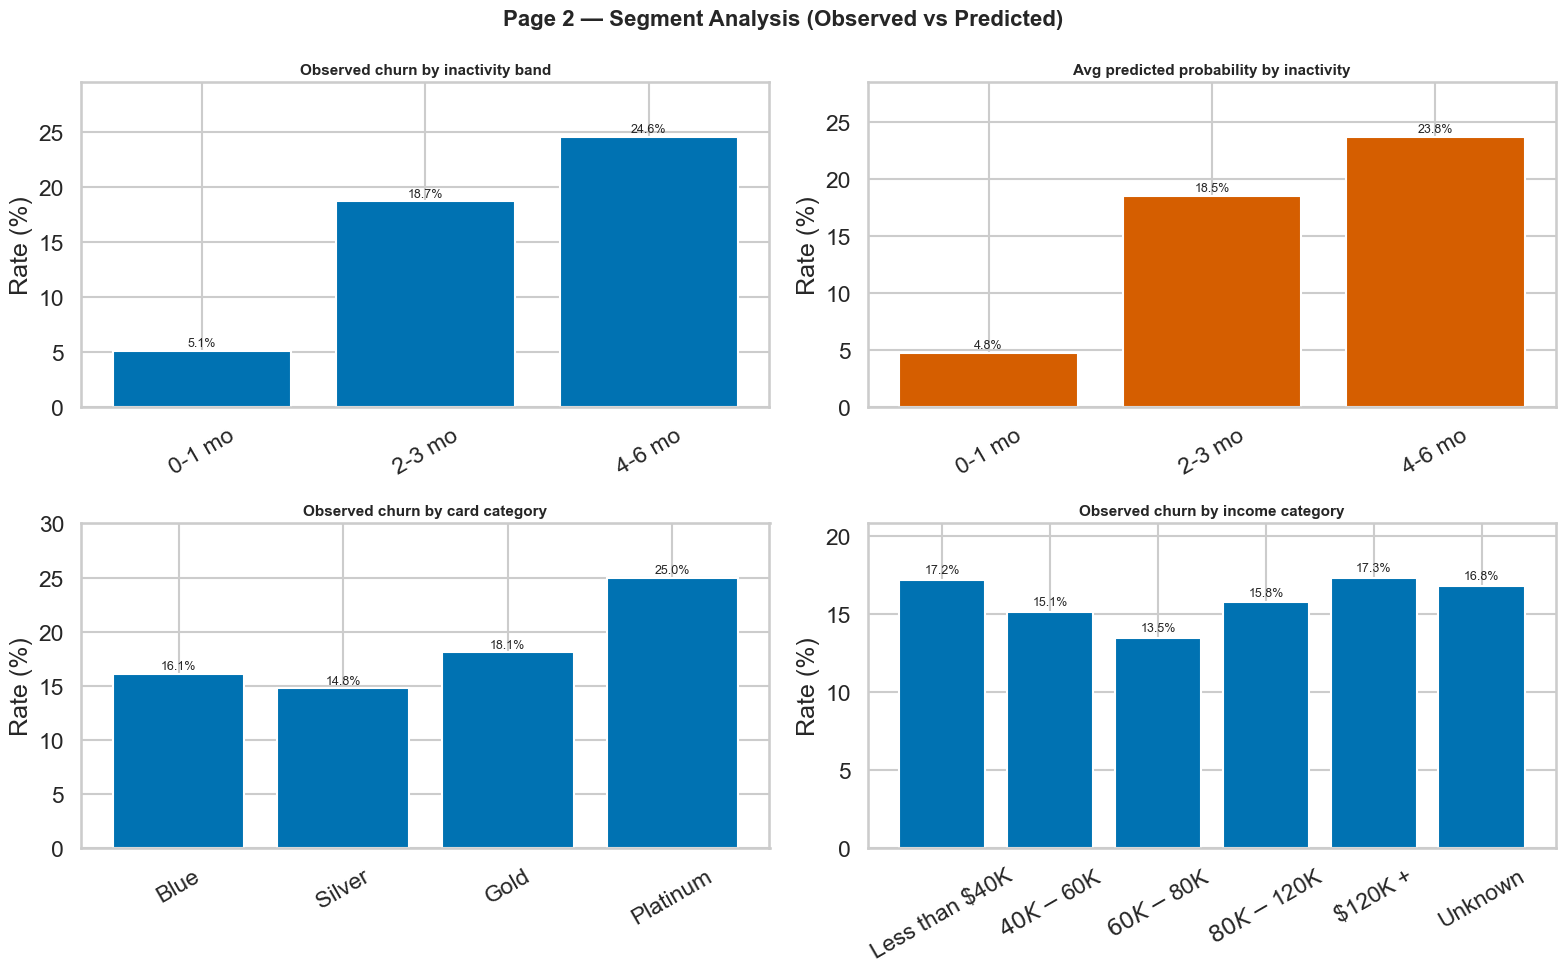

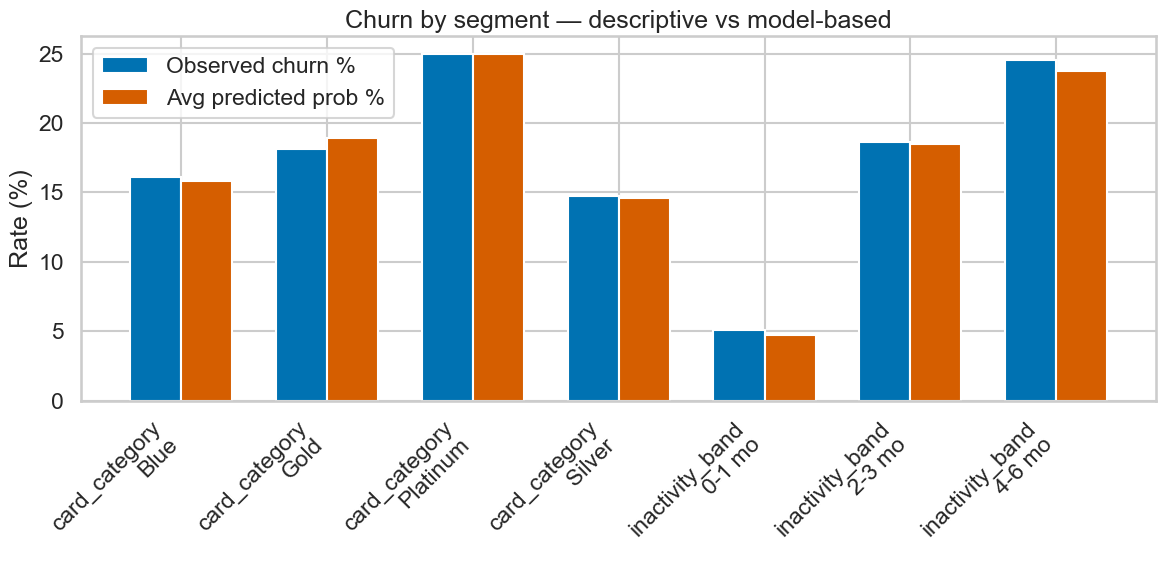

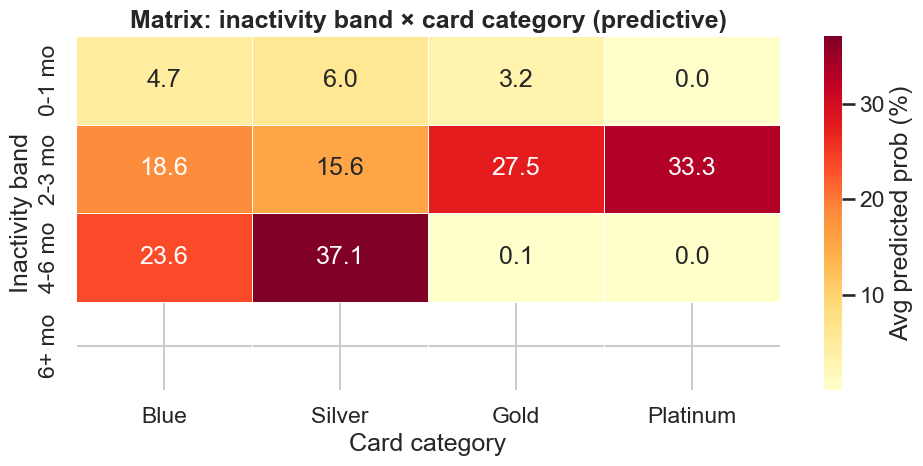

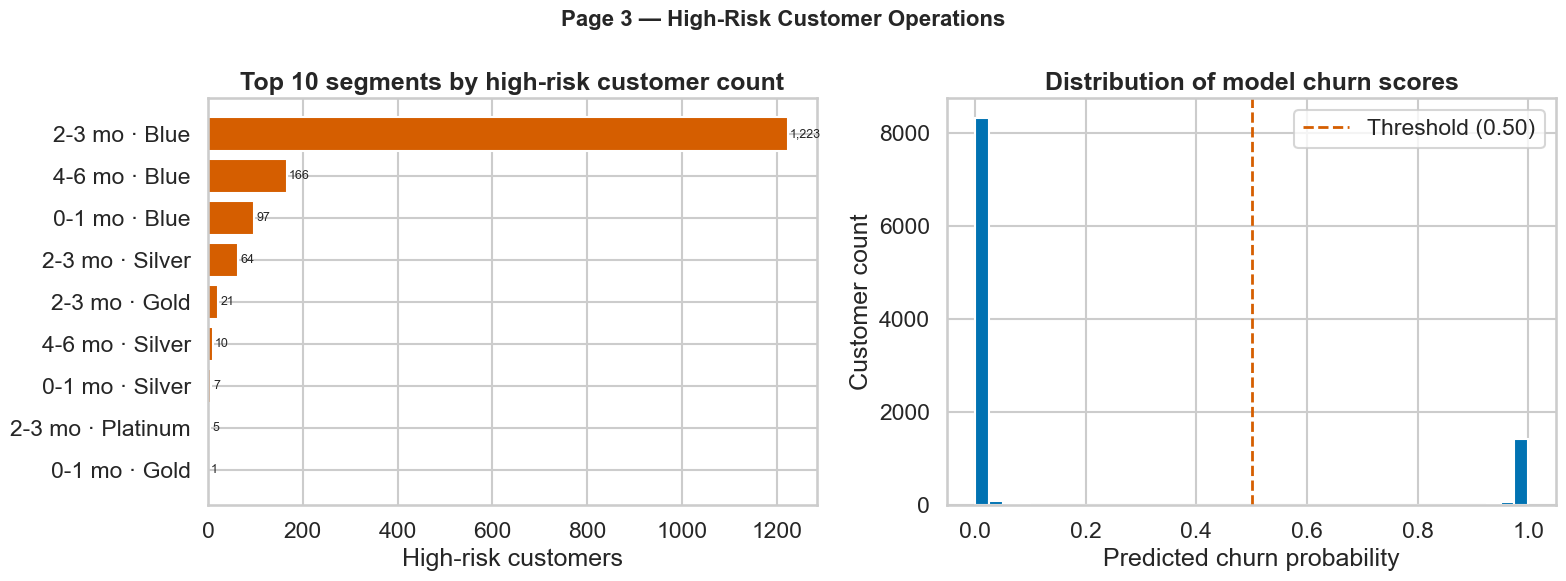

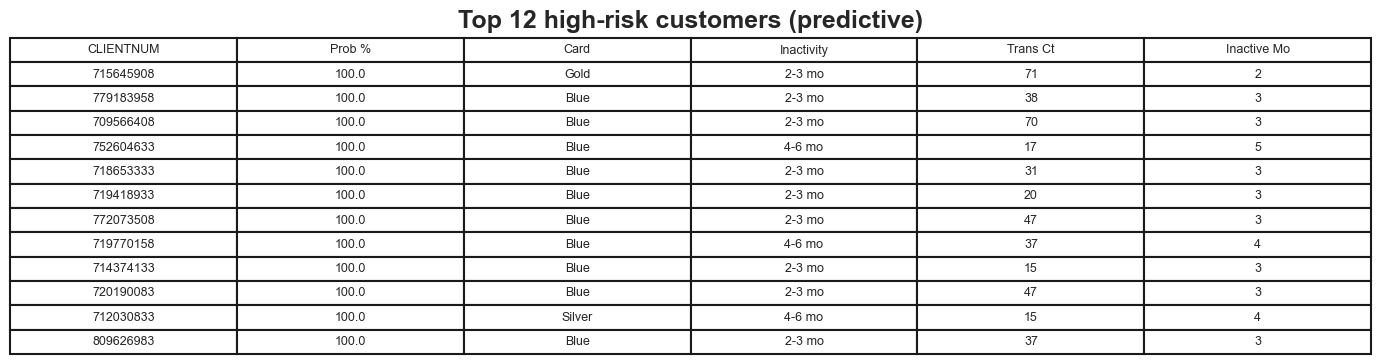

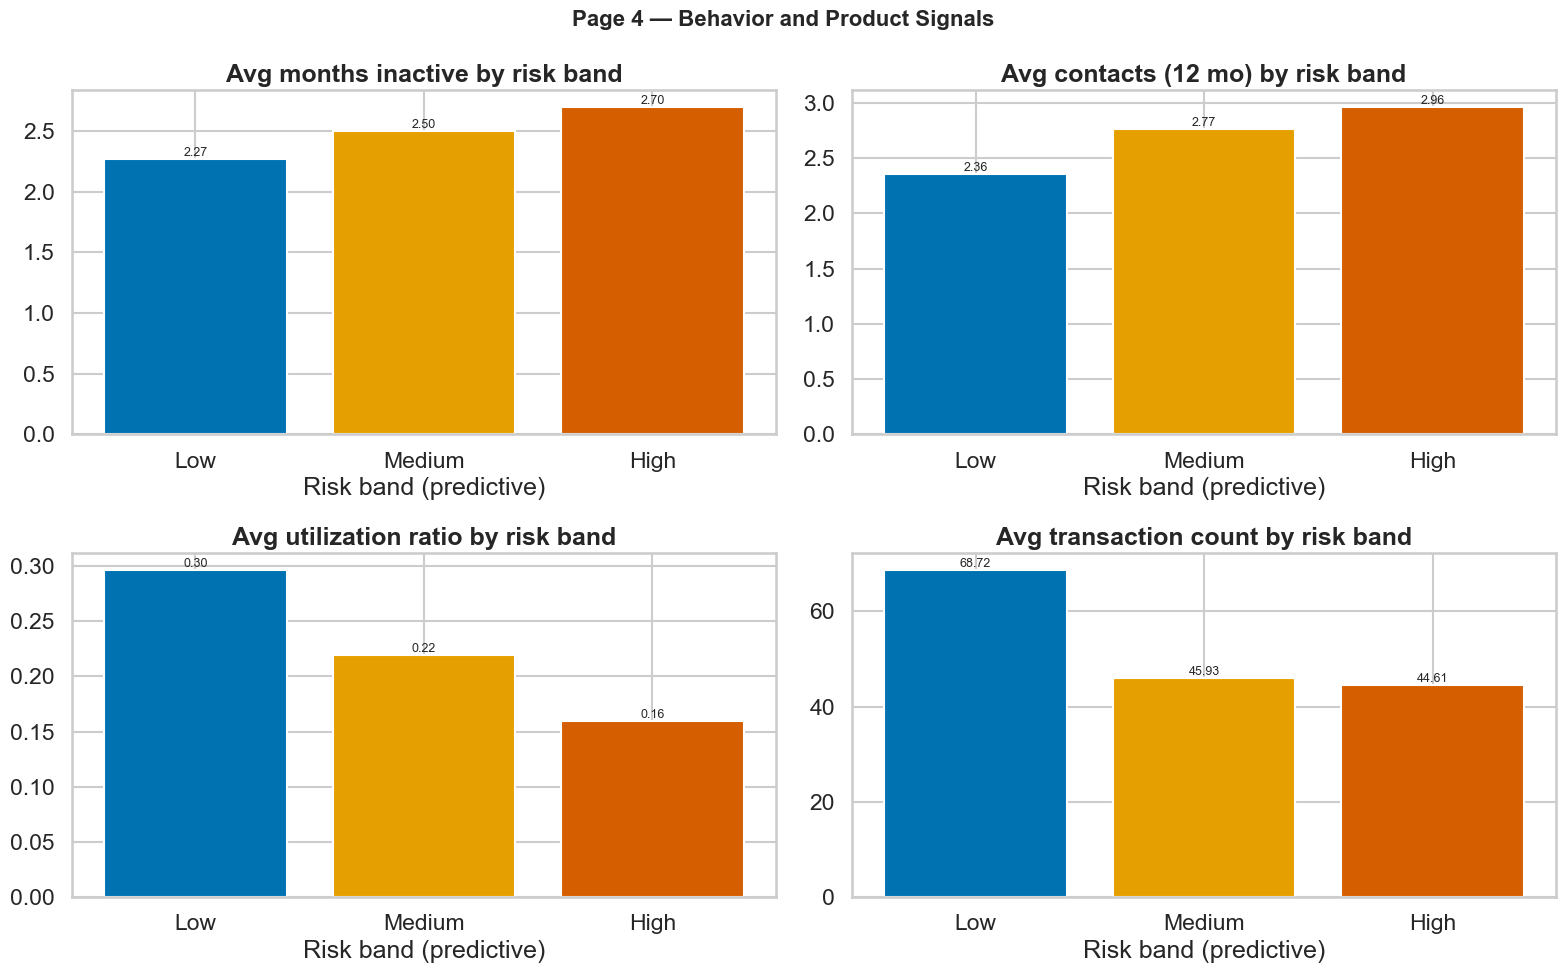

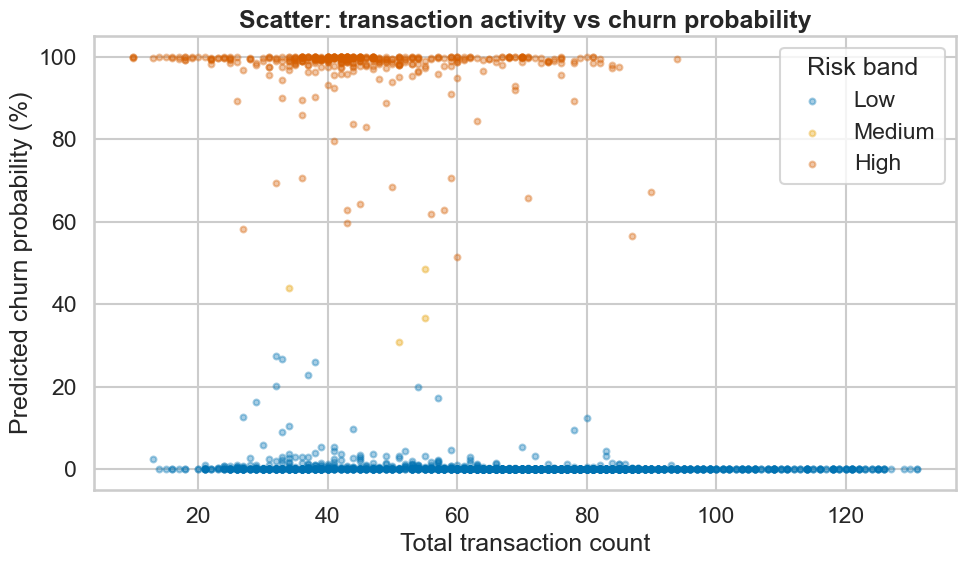

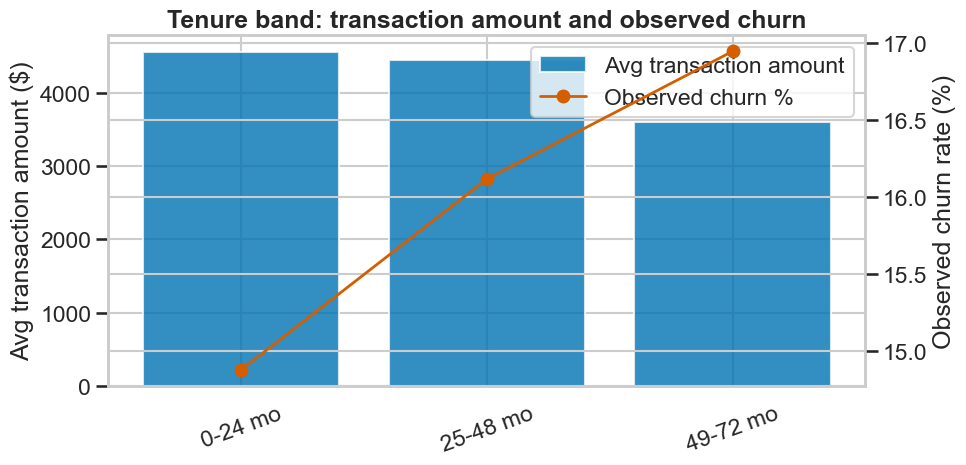

Saved 11 Power BI-style figures to C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp\reports\figures
  - pbi_dashboard_page1.png


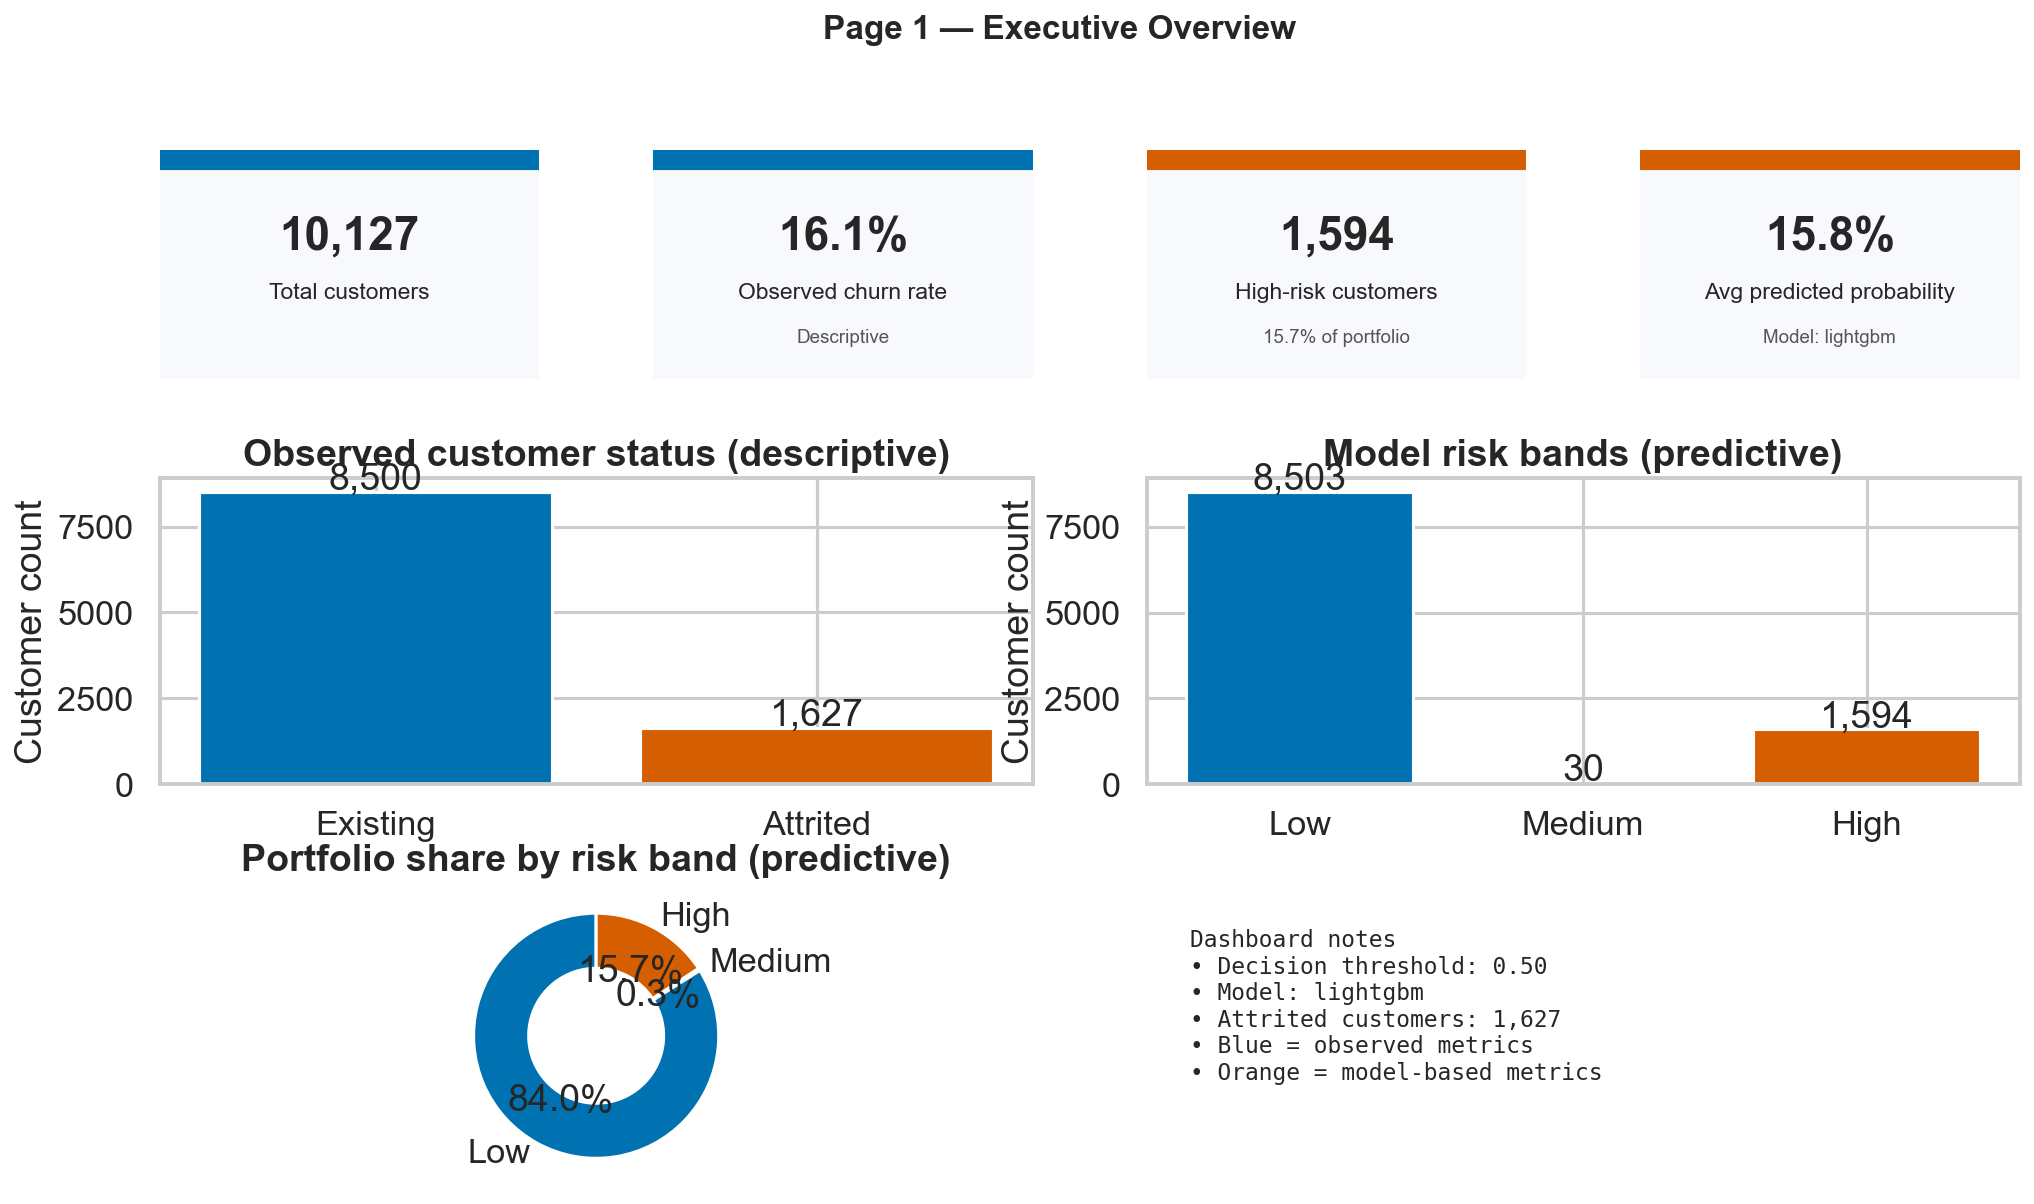

  - pbi_dashboard_page2.png


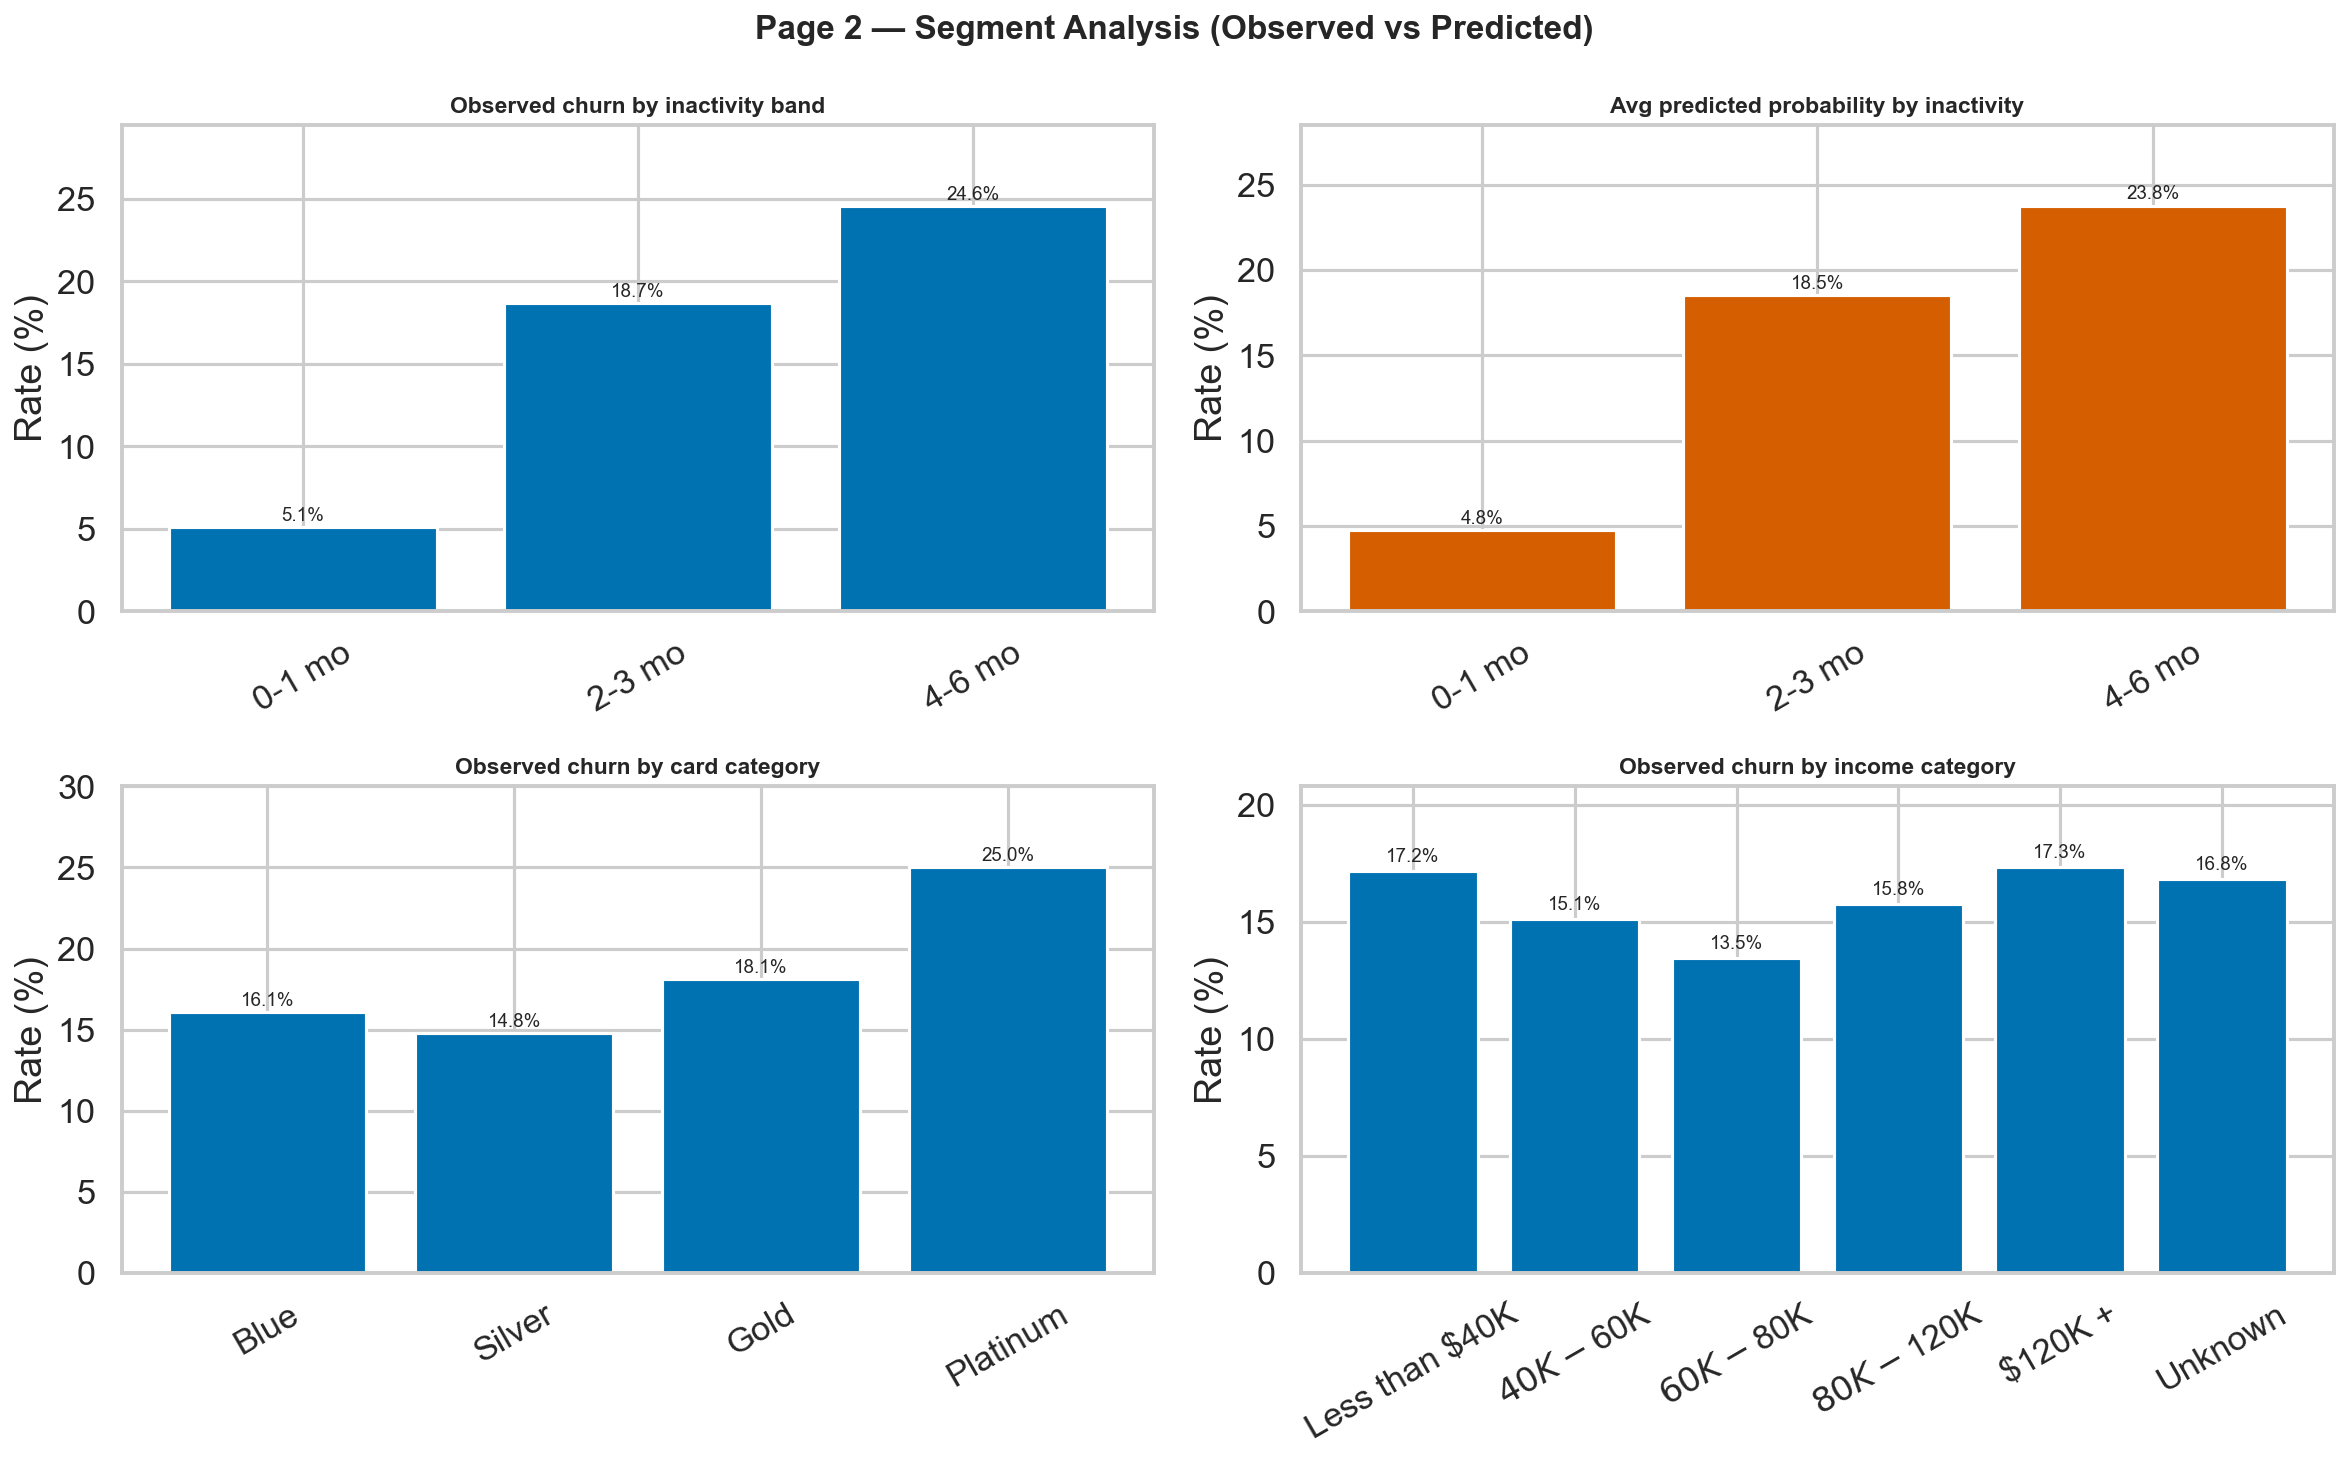

  - pbi_dashboard_page3.png


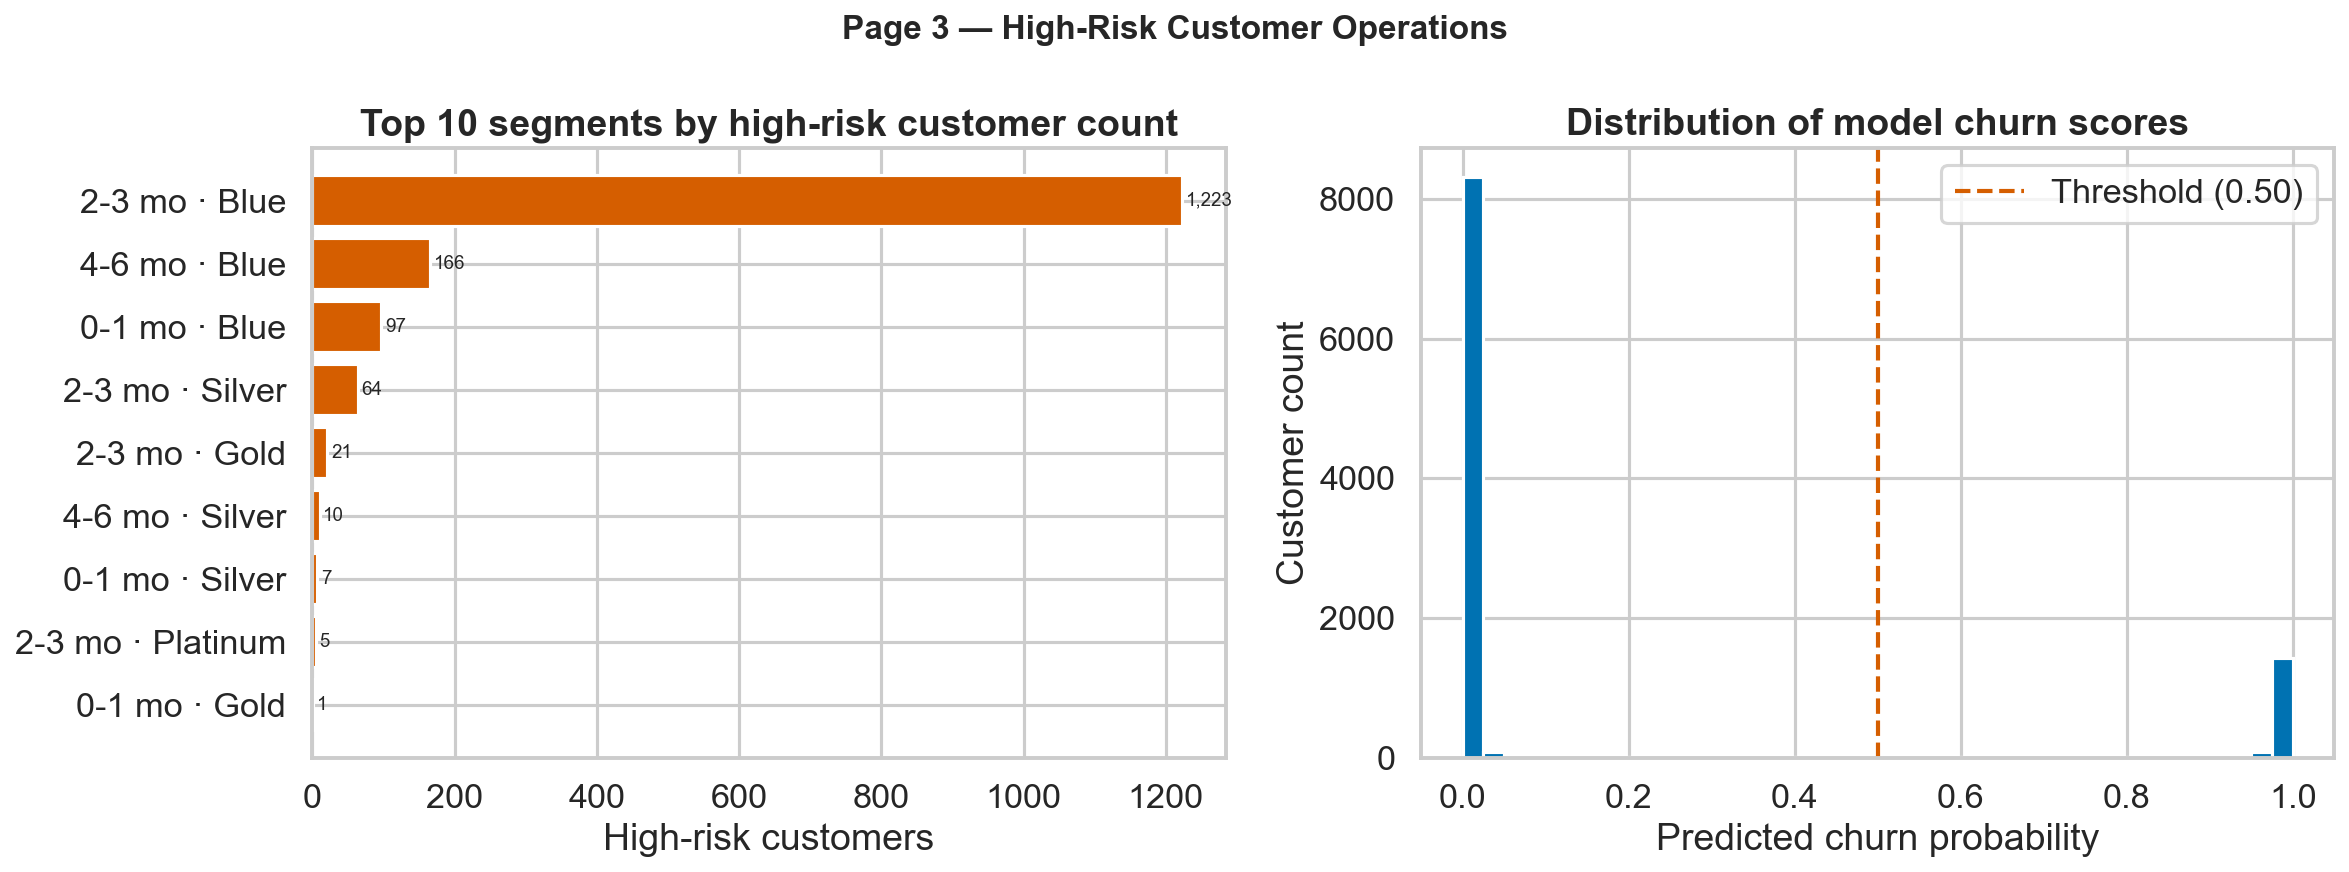

  - pbi_dashboard_page4.png


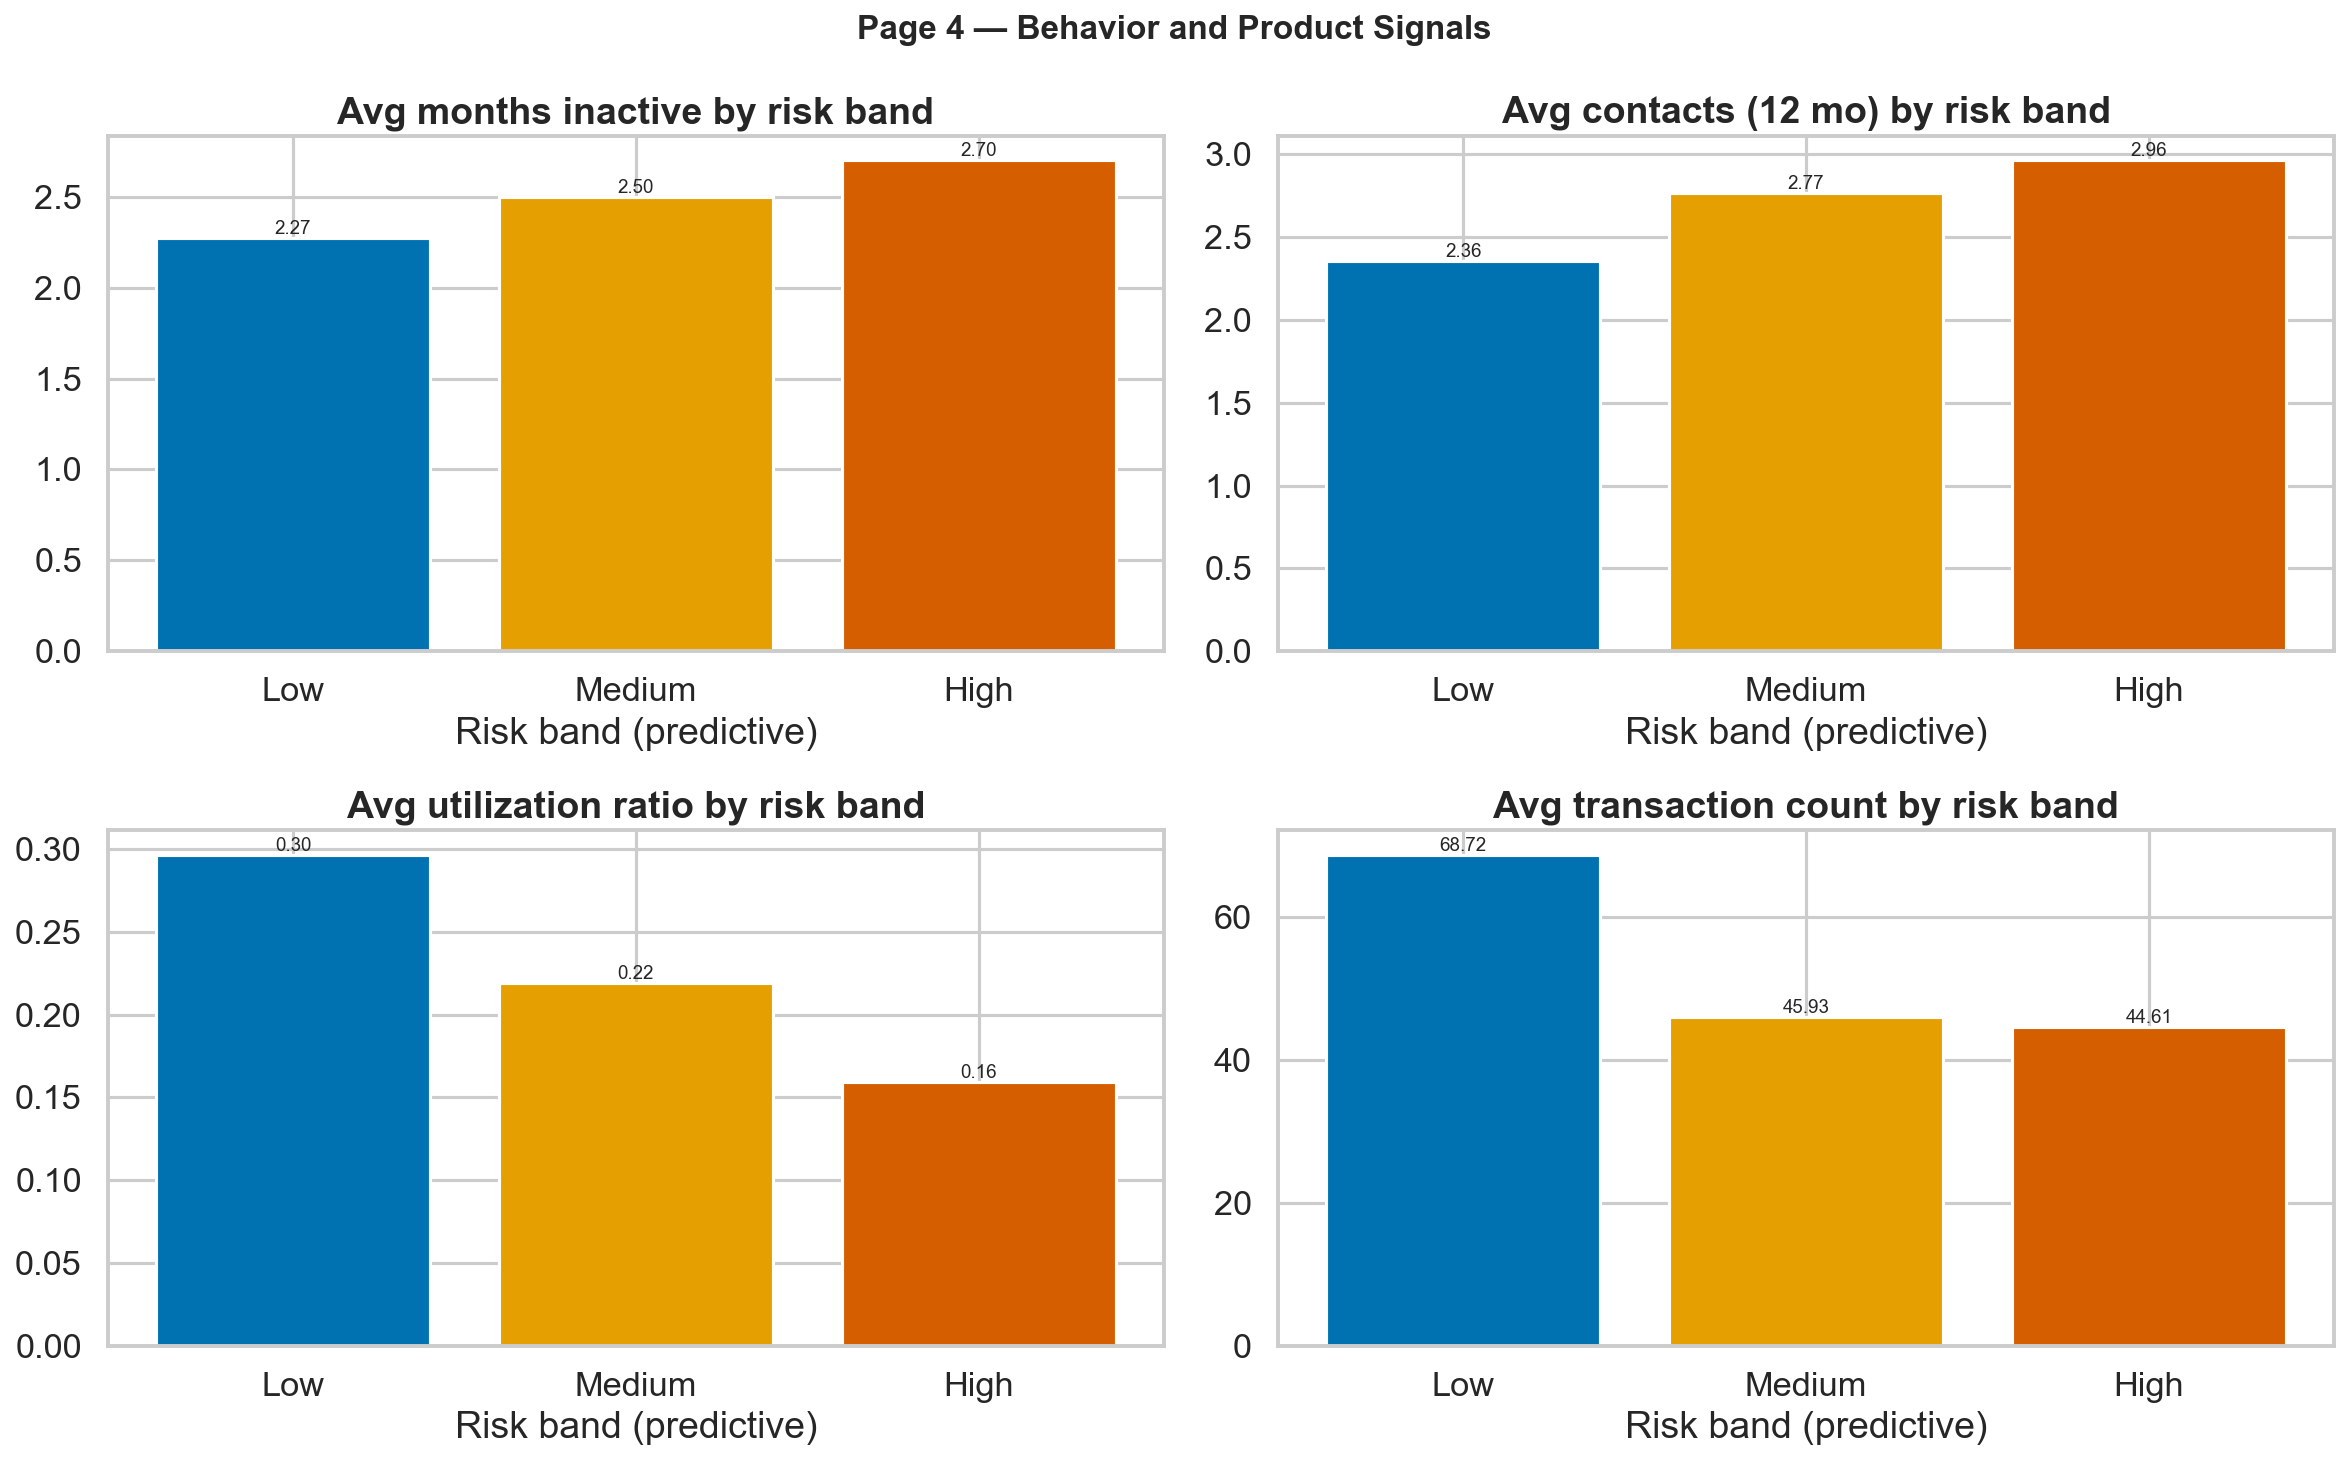

  - pbi_high_risk_customer_table.png


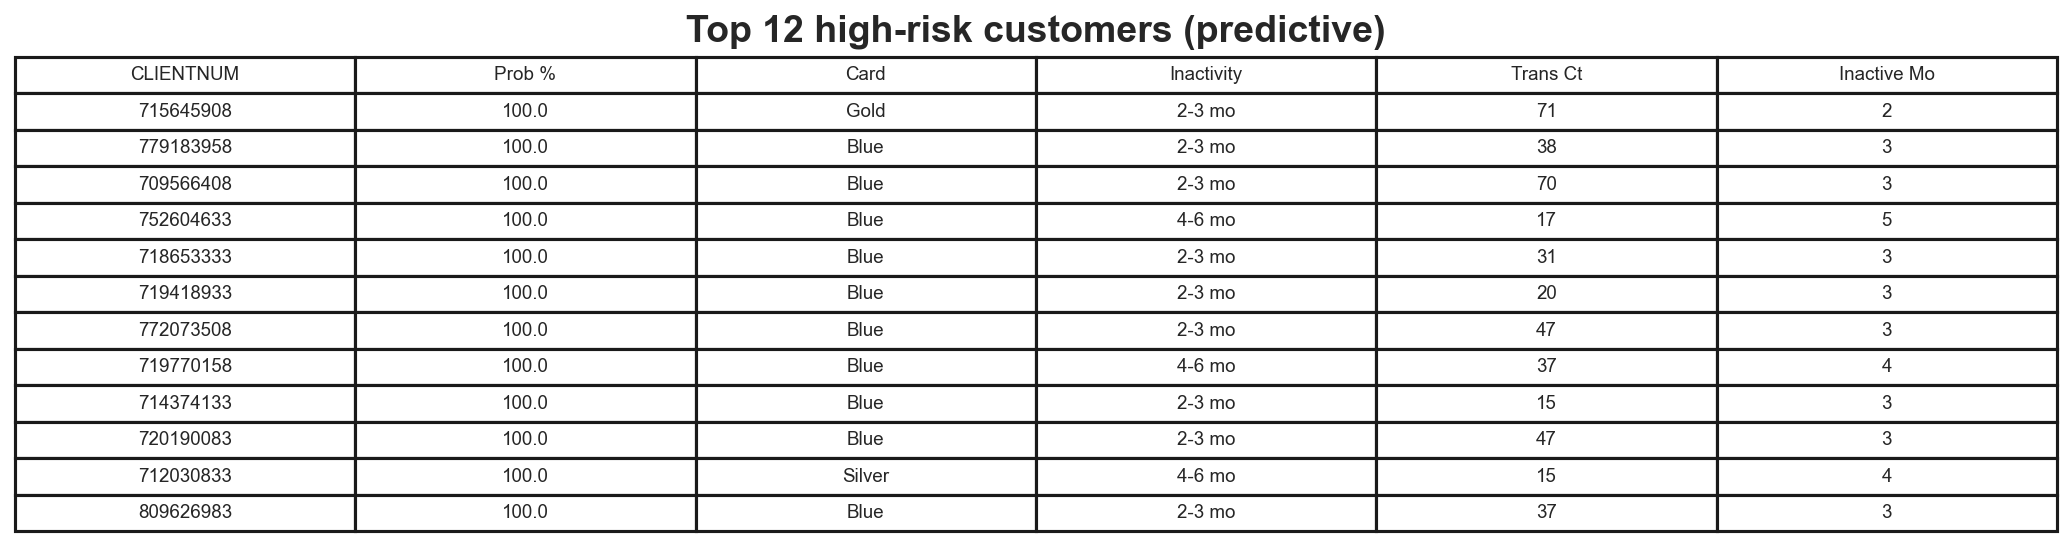

  - pbi_scatter_trans_vs_probability.png


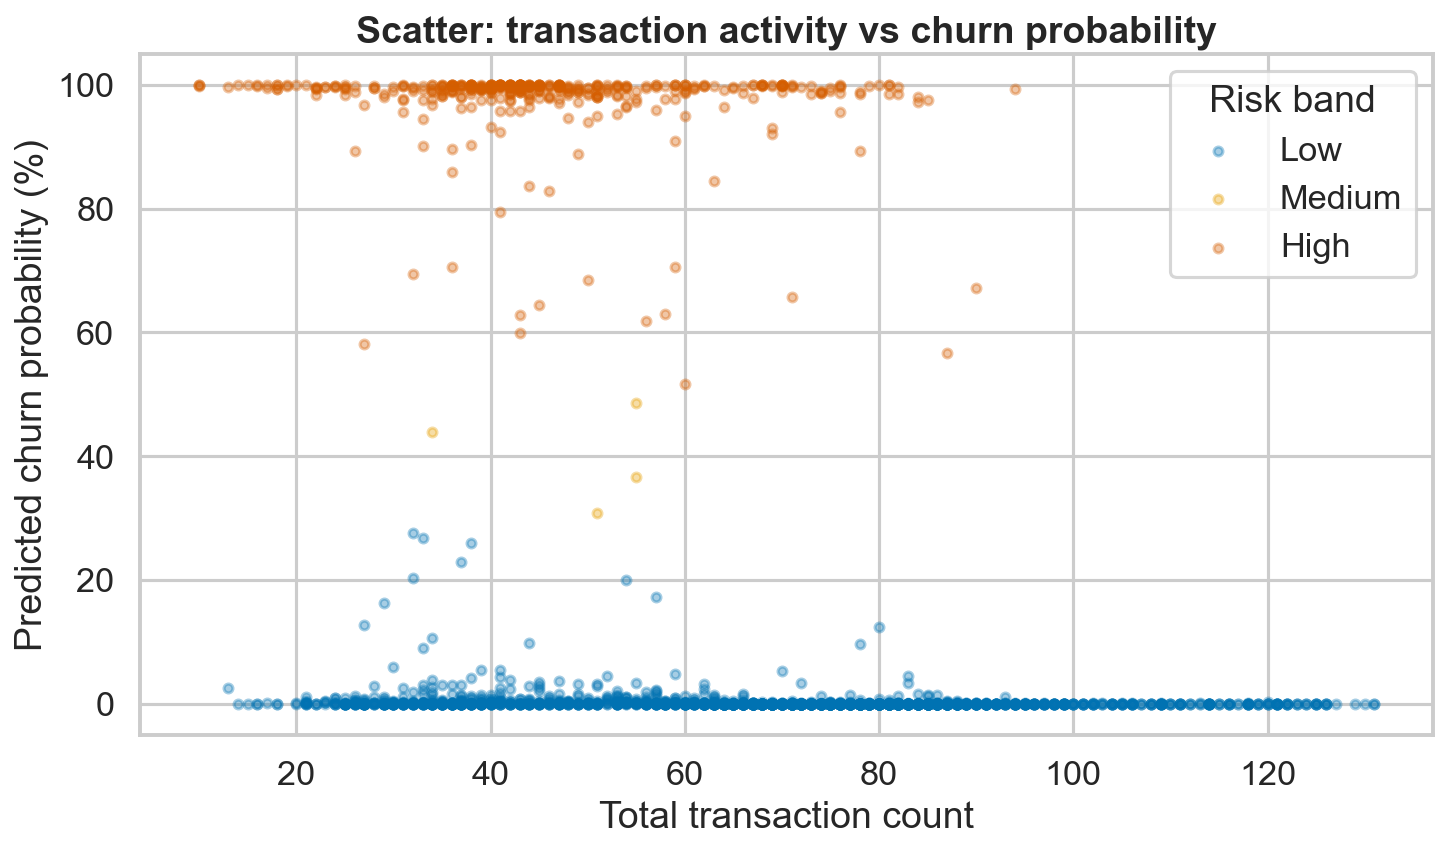

  - pbi_segment_heatmap_inactivity_card.png


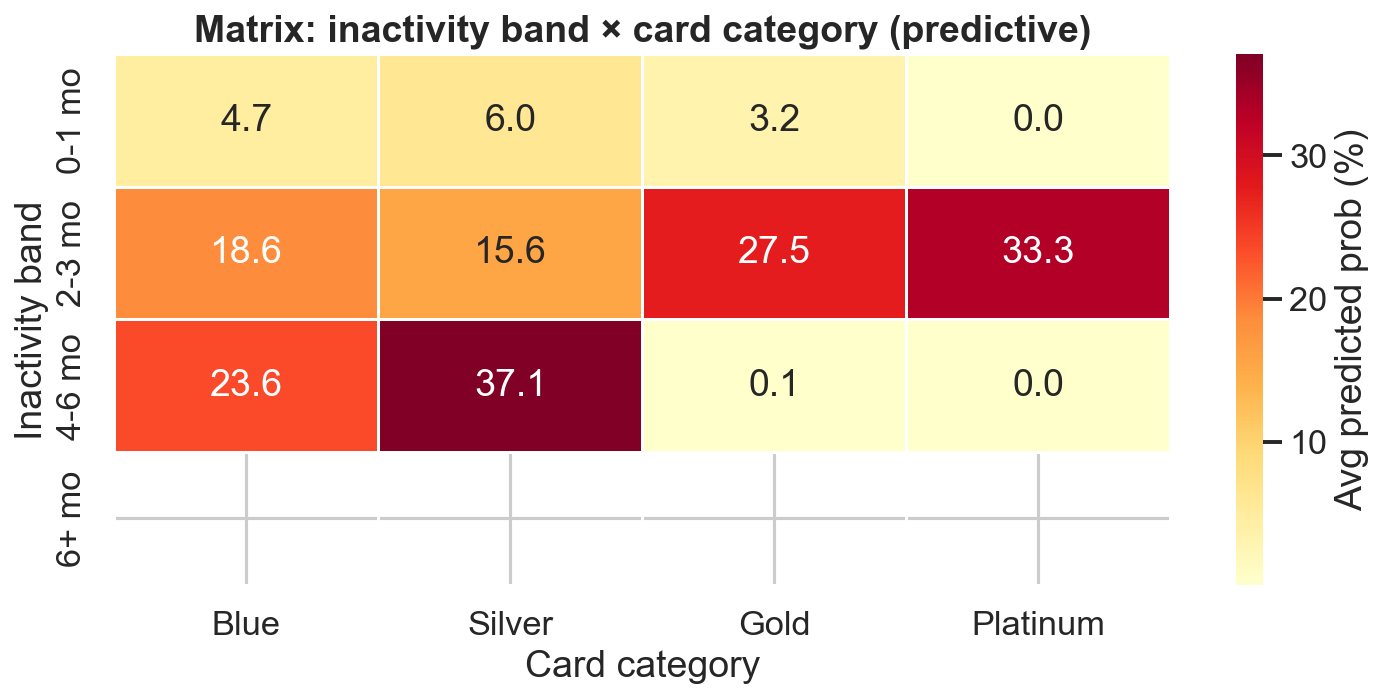

  - pbi_trans_amt_by_tenure.png


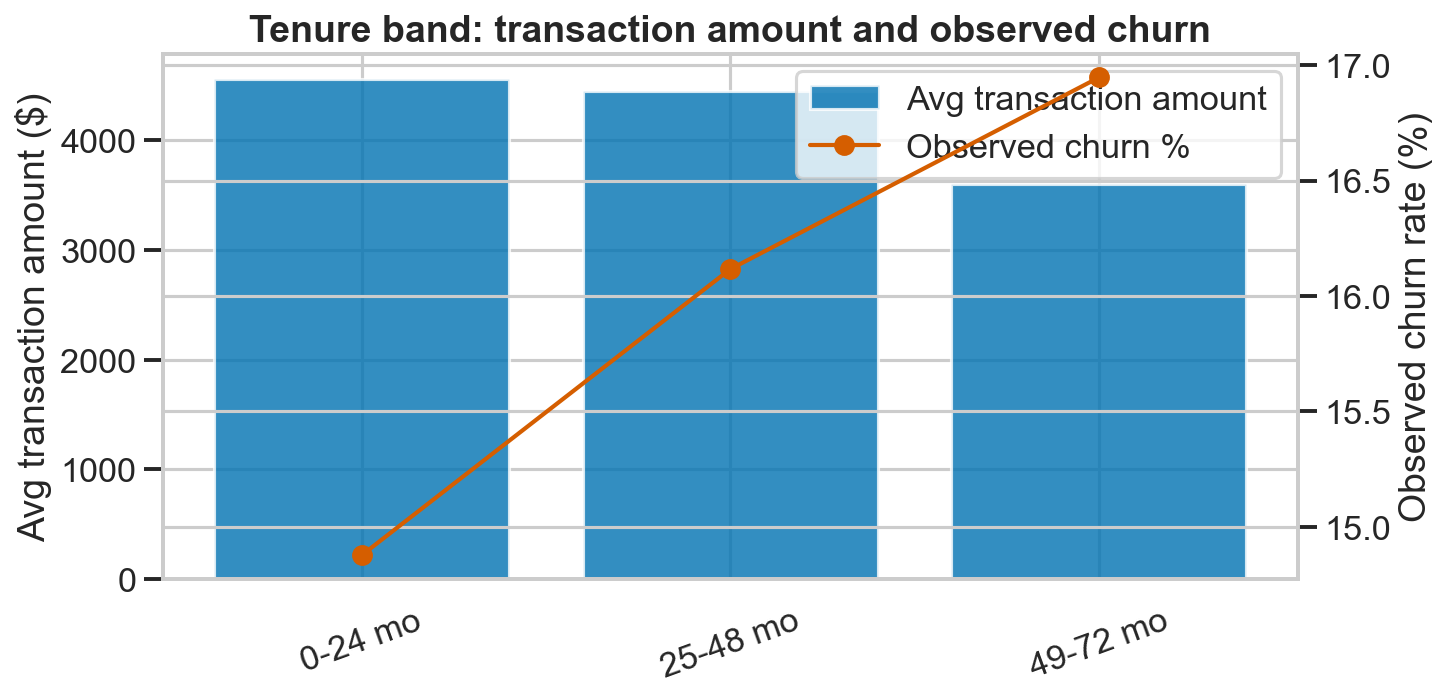

  - churn_overview.png


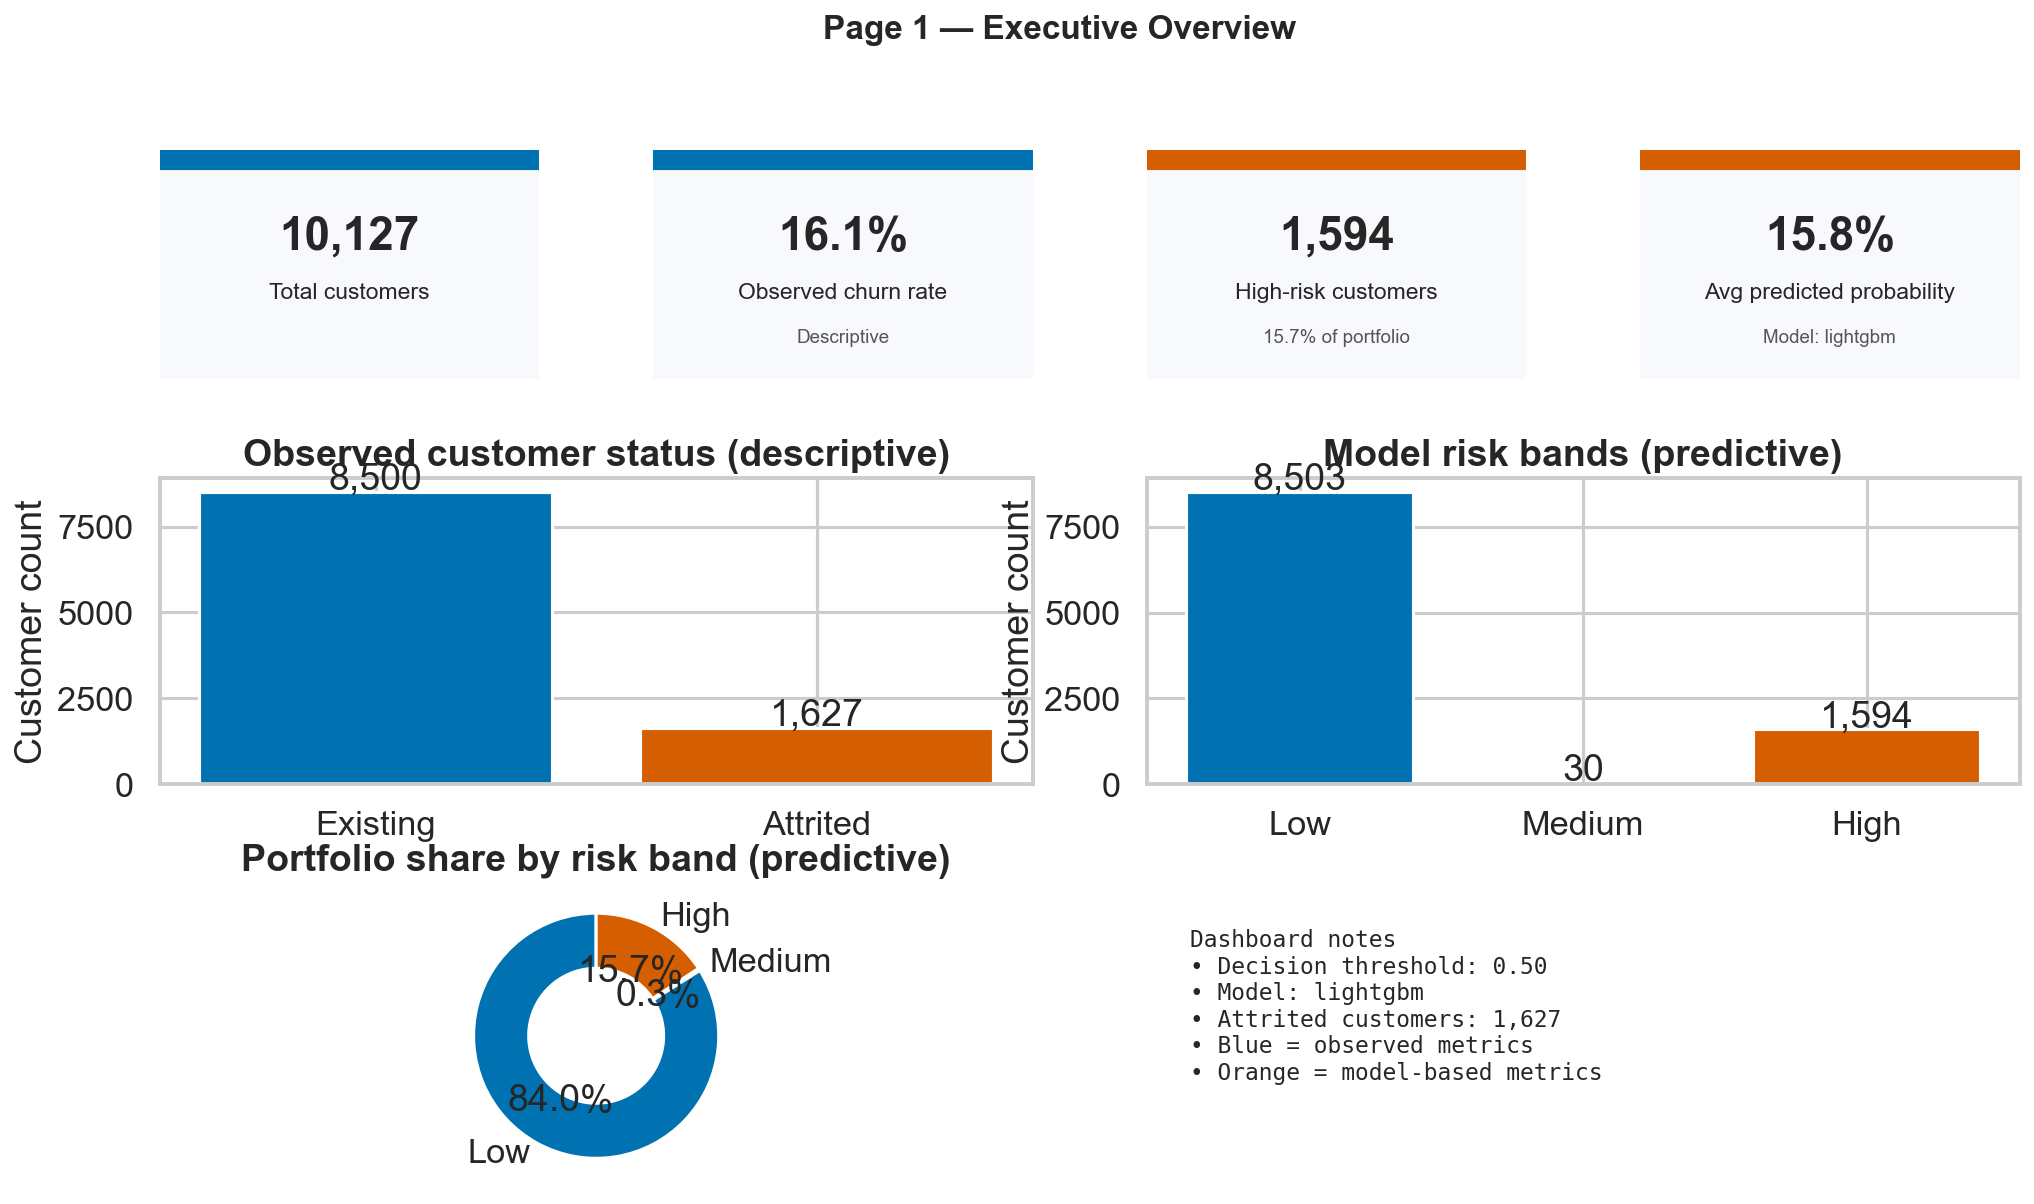

  - churn_by_segment.png


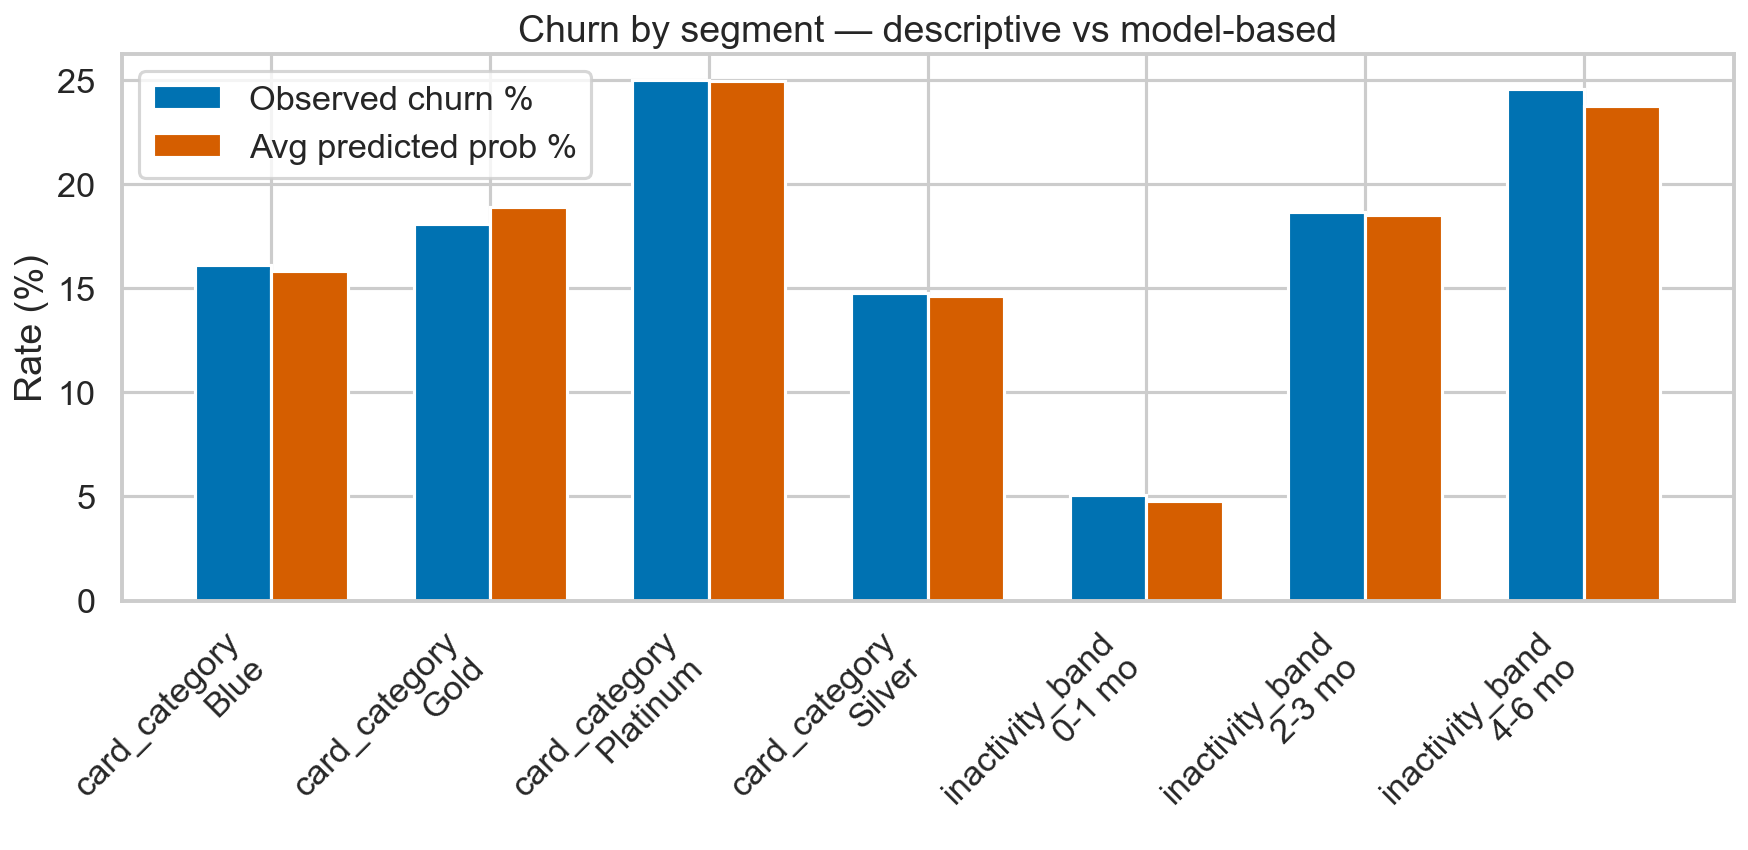

  - churn_model_risk_distribution.png


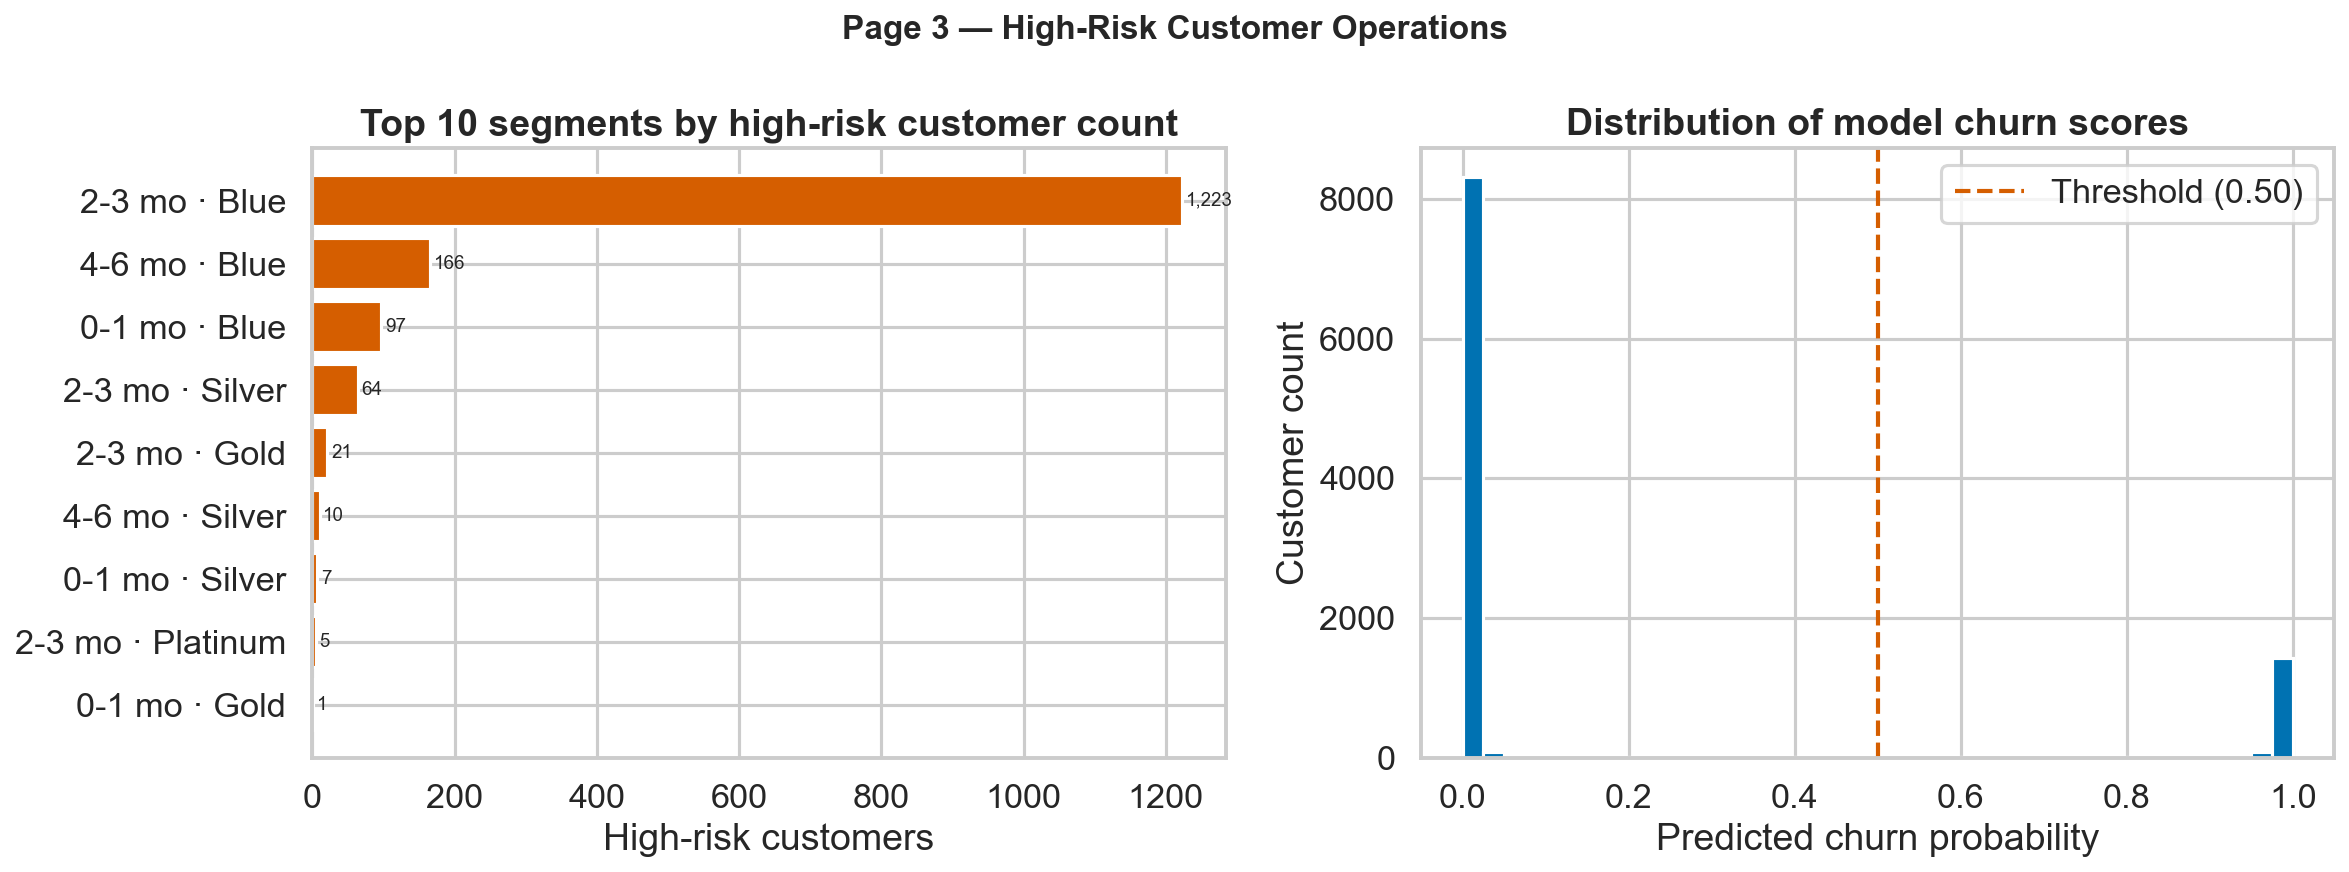

In [5]:
# --- Power BI palette and helpers ---
COLOR_OBSERVED = "#0072B2"
COLOR_PREDICTED = "#D55E00"
COLOR_MEDIUM = "#E69F00"
RISK_COLORS = {"Low": COLOR_OBSERVED, "Medium": COLOR_MEDIUM, "High": COLOR_PREDICTED}

SEGMENT_ORDERS = {
    "inactivity_band": ["0-1 mo", "2-3 mo", "4-6 mo", "6+ mo"],
    "Card_Category": ["Blue", "Silver", "Gold", "Platinum"],
    "Income_Category": [
        "Less than $40K", "$40K - $60K", "$60K - $80K", "$80K - $120K", "$120K +", "Unknown",
    ],
    "age_band": ["Under 35", "35-49", "50-64", "65+"],
    "tenure_band": ["0-24 mo", "25-48 mo", "49-72 mo", "73+ mo"],
}


def _ordered_segment(df: pd.DataFrame, dimension: str, order_key: str) -> pd.DataFrame:
    out = df[df["segment_dimension"] == dimension].copy()
    order = SEGMENT_ORDERS.get(order_key, sorted(out["segment_value"].astype(str).unique()))
    out["segment_value"] = pd.Categorical(out["segment_value"], categories=order, ordered=True)
    return out.sort_values("segment_value")


def _rate_bar(ax, data: pd.DataFrame, y_col: str, title: str, color: str, ylabel: str = "Rate (%)") -> None:
    labels = data["segment_value"].astype(str)
    values = data[y_col]
    bars = ax.bar(labels, values, color=color, edgecolor="white")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(values.max() * 1.2, 5))
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4, f"{val:.1f}%", ha="center", fontsize=9)


def _kpi_card(ax, label: str, value: str, subtitle: str = "", color: str = COLOR_OBSERVED) -> None:
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, color="#F7F9FC", zorder=0))
    ax.add_patch(plt.Rectangle((0, 0.92), 1, 0.08, transform=ax.transAxes, color=color, zorder=1))
    ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=22, fontweight="bold", transform=ax.transAxes)
    ax.text(0.5, 0.38, label, ha="center", va="center", fontsize=11, transform=ax.transAxes)
    if subtitle:
        ax.text(0.5, 0.18, subtitle, ha="center", va="center", fontsize=9, color="#555555", transform=ax.transAxes)


# --- Page 1: Executive overview ---
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(3, 4, height_ratios=[0.9, 1.2, 1.2], hspace=0.35, wspace=0.3)
fig.suptitle("Page 1 — Executive Overview", fontsize=16, fontweight="bold", y=0.98)

_kpi_card(fig.add_subplot(gs[0, 0]), "Total customers", f"{total_customers:,}")
_kpi_card(fig.add_subplot(gs[0, 1]), "Observed churn rate", f"{observed_rate:.1f}%", "Descriptive", COLOR_OBSERVED)
_kpi_card(fig.add_subplot(gs[0, 2]), "High-risk customers", f"{high_risk_count:,}", f"{high_risk_rate:.1f}% of portfolio", COLOR_PREDICTED)
_kpi_card(fig.add_subplot(gs[0, 3]), "Avg predicted probability", f"{avg_prob:.1f}%", f"Model: {model_name}", COLOR_PREDICTED)

ax_status = fig.add_subplot(gs[1, 0:2])
ax_status.bar(["Existing", "Attrited"], [total_customers - attrited, attrited], color=[COLOR_OBSERVED, COLOR_PREDICTED])
ax_status.set_title("Observed customer status (descriptive)", fontweight="bold")
ax_status.set_ylabel("Customer count")
for i, v in enumerate([total_customers - attrited, attrited]):
    ax_status.text(i, v + 80, f"{v:,}", ha="center")

ax_risk = fig.add_subplot(gs[1, 2:4])
risk_counts = master["risk_band"].value_counts().reindex(["Low", "Medium", "High"]).fillna(0)
ax_risk.bar(risk_counts.index, risk_counts.values, color=[RISK_COLORS[b] for b in risk_counts.index])
ax_risk.set_title("Model risk bands (predictive)", fontweight="bold")
ax_risk.set_ylabel("Customer count")
for i, v in enumerate(risk_counts.values):
    ax_risk.text(i, v + 80, f"{int(v):,}", ha="center")

ax_donut = fig.add_subplot(gs[2, 0:2])
wedges, _, autotexts = ax_donut.pie(
    risk_counts.values,
    labels=risk_counts.index,
    autopct="%1.1f%%",
    colors=[RISK_COLORS[b] for b in risk_counts.index],
    startangle=90,
    wedgeprops={"width": 0.45, "edgecolor": "white"},
)
ax_donut.set_title("Portfolio share by risk band (predictive)", fontweight="bold")

ax_meta = fig.add_subplot(gs[2, 2:4])
ax_meta.axis("off")
meta_lines = [
    "Dashboard notes",
    f"• Decision threshold: {threshold:.2f}",
    f"• Model: {model_name}",
    f"• Attrited customers: {attrited:,}",
    "• Blue = observed metrics",
    "• Orange = model-based metrics",
]
ax_meta.text(0.05, 0.85, "\n".join(meta_lines), va="top", fontsize=11, family="monospace")

fig.savefig(FIG_DIR / "pbi_dashboard_page1.png", bbox_inches="tight", dpi=150)
fig.savefig(FIG_DIR / "churn_overview.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

# --- Page 2: Segment analysis ---
inactivity = _ordered_segment(churn_by_segment, "inactivity_band", "inactivity_band")
card_seg = _ordered_segment(churn_by_segment, "card_category", "Card_Category")
income_seg = _ordered_segment(churn_by_segment, "income_category", "Income_Category")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Page 2 — Segment Analysis (Observed vs Predicted)", fontsize=16, fontweight="bold")

_rate_bar(axes[0, 0], inactivity, "observed_churn_rate_pct", "Observed churn by inactivity band", COLOR_OBSERVED)
_rate_bar(axes[0, 1], inactivity, "avg_churn_probability_pct", "Avg predicted probability by inactivity", COLOR_PREDICTED)
_rate_bar(axes[1, 0], card_seg, "observed_churn_rate_pct", "Observed churn by card category", COLOR_OBSERVED)
_rate_bar(axes[1, 1], income_seg, "observed_churn_rate_pct", "Observed churn by income category", COLOR_OBSERVED)

fig.tight_layout()
fig.savefig(FIG_DIR / "pbi_dashboard_page2.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

# Combined segment chart (legacy + Power BI style)
seg_plot = churn_by_segment[churn_by_segment["segment_dimension"].isin(["card_category", "inactivity_band"])]
fig, ax = plt.subplots(figsize=(12, 6))
x_labels, obs_rates, pred_rates = [], [], []
for _, row in seg_plot.iterrows():
    x_labels.append(f"{row['segment_dimension']}\n{row['segment_value']}")
    obs_rates.append(row["observed_churn_rate_pct"])
    pred_rates.append(row["avg_churn_probability_pct"])
x = np.arange(len(x_labels))
width = 0.35
ax.bar(x - width / 2, obs_rates, width, label="Observed churn %", color=COLOR_OBSERVED)
ax.bar(x + width / 2, pred_rates, width, label="Avg predicted prob %", color=COLOR_PREDICTED)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.set_ylabel("Rate (%)")
ax.set_title("Churn by segment — descriptive vs model-based")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "churn_by_segment.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

# Heatmap matrix: inactivity x card (avg predicted probability)
heatmap_data = (
    master.groupby(["inactivity_band", "Card_Category"], observed=True)["churn_probability"]
    .mean()
    .unstack(fill_value=0)
    .reindex(index=SEGMENT_ORDERS["inactivity_band"], columns=SEGMENT_ORDERS["Card_Category"])
    * 100
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5, ax=ax, cbar_kws={"label": "Avg predicted prob (%)"})
ax.set_title("Matrix: inactivity band × card category (predictive)", fontweight="bold")
ax.set_xlabel("Card category")
ax.set_ylabel("Inactivity band")
fig.tight_layout()
fig.savefig(FIG_DIR / "pbi_segment_heatmap_inactivity_card.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

# --- Page 3: High-risk operations ---
high_risk_master = master[master["is_high_risk"]].copy()
segment_hr = (
    high_risk_master.groupby(["inactivity_band", "Card_Category"], observed=True)
    .size()
    .reset_index(name="high_risk_count")
    .sort_values("high_risk_count", ascending=False)
    .head(10)
)
segment_hr["label"] = segment_hr["inactivity_band"] + " · " + segment_hr["Card_Category"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Page 3 — High-Risk Customer Operations", fontsize=16, fontweight="bold")

axes[0].barh(segment_hr["label"][::-1], segment_hr["high_risk_count"][::-1], color=COLOR_PREDICTED)
axes[0].set_title("Top 10 segments by high-risk customer count", fontweight="bold")
axes[0].set_xlabel("High-risk customers")
for i, v in enumerate(segment_hr["high_risk_count"][::-1]):
    axes[0].text(v + 5, i, f"{int(v):,}", va="center", fontsize=9)

axes[1].hist(master["churn_probability"], bins=40, color=COLOR_OBSERVED, edgecolor="white")
axes[1].axvline(threshold, color=COLOR_PREDICTED, linestyle="--", linewidth=2, label=f"Threshold ({threshold:.2f})")
axes[1].set_xlabel("Predicted churn probability")
axes[1].set_ylabel("Customer count")
axes[1].set_title("Distribution of model churn scores", fontweight="bold")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "pbi_dashboard_page3.png", bbox_inches="tight", dpi=150)
fig.savefig(FIG_DIR / "churn_model_risk_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

# Top 12 high-risk customers table (Power BI table visual equivalent)
top_hr = high_risk_master.nlargest(12, "churn_probability")[
    ["CLIENTNUM", "churn_probability", "Card_Category", "inactivity_band", "Total_Trans_Ct", "Months_Inactive_12_mon"]
].copy()
top_hr["churn_probability"] = (top_hr["churn_probability"] * 100).round(1)
top_hr.columns = ["CLIENTNUM", "Prob %", "Card", "Inactivity", "Trans Ct", "Inactive Mo"]

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")
table = ax.table(
    cellText=top_hr.values,
    colLabels=top_hr.columns,
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.6)
ax.set_title("Top 12 high-risk customers (predictive)", fontweight="bold", pad=20)
fig.tight_layout()
fig.savefig(FIG_DIR / "pbi_high_risk_customer_table.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

# --- Page 4: Behavior and product signals ---
behavior_metrics = (
    master.groupby("risk_band", observed=True)
    .agg(
        avg_inactive=("Months_Inactive_12_mon", "mean"),
        avg_contacts=("Contacts_Count_12_mon", "mean"),
        avg_utilization=("Avg_Utilization_Ratio", "mean"),
        avg_trans_ct=("Total_Trans_Ct", "mean"),
    )
    .reindex(["Low", "Medium", "High"])
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Page 4 — Behavior and Product Signals", fontsize=16, fontweight="bold")

for ax, col, title in zip(
    axes.flat,
    ["avg_inactive", "avg_contacts", "avg_utilization", "avg_trans_ct"],
    [
        "Avg months inactive by risk band",
        "Avg contacts (12 mo) by risk band",
        "Avg utilization ratio by risk band",
        "Avg transaction count by risk band",
    ],
):
    vals = behavior_metrics[col]
    bars = ax.bar(vals.index, vals.values, color=[RISK_COLORS[b] for b in vals.index])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Risk band (predictive)")
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.2f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "pbi_dashboard_page4.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

# Scatter: transactions vs churn probability
sample_scatter = master.sample(n=min(2500, len(master)), random_state=42)
fig, ax = plt.subplots(figsize=(10, 6))
for band, color in RISK_COLORS.items():
    subset = sample_scatter[sample_scatter["risk_band"] == band]
    ax.scatter(
        subset["Total_Trans_Ct"],
        subset["churn_probability"] * 100,
        alpha=0.35,
        s=18,
        label=band,
        color=color,
    )
ax.set_xlabel("Total transaction count")
ax.set_ylabel("Predicted churn probability (%)")
ax.set_title("Scatter: transaction activity vs churn probability", fontweight="bold")
ax.legend(title="Risk band")
fig.tight_layout()
fig.savefig(FIG_DIR / "pbi_scatter_trans_vs_probability.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

# Observed avg transaction amount by tenure band
tenure_obs = (
    master.groupby("tenure_band", observed=True)
    .agg(avg_trans_amt=("Total_Trans_Amt", "mean"), observed_churn_rate=("observed_churn", "mean"))
    .reindex(SEGMENT_ORDERS["tenure_band"])
)
x = np.arange(len(tenure_obs))
fig, ax1 = plt.subplots(figsize=(10, 5))
bars = ax1.bar(x, tenure_obs["avg_trans_amt"], color=COLOR_OBSERVED, alpha=0.8, label="Avg transaction amount")
ax1.set_ylabel("Avg transaction amount ($)")
ax1.set_xticks(x)
ax1.set_xticklabels(tenure_obs.index, rotation=20)
ax2 = ax1.twinx()
ax2.plot(x, tenure_obs["observed_churn_rate"] * 100, color=COLOR_PREDICTED, marker="o", linewidth=2, label="Observed churn %")
ax2.set_ylabel("Observed churn rate (%)")
ax1.set_title("Tenure band: transaction amount and observed churn", fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "pbi_trans_amt_by_tenure.png", bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)

# Preview saved dashboard pages
pbi_figures = sorted(FIG_DIR.glob("pbi_*.png")) + [
    FIG_DIR / "churn_overview.png",
    FIG_DIR / "churn_by_segment.png",
    FIG_DIR / "churn_model_risk_distribution.png",
]
print(f"Saved {len(pbi_figures)} Power BI-style figures to {FIG_DIR}")
for fig_path in pbi_figures:
    print(f"  - {fig_path.name}")
    display(Image(filename=fig_path))


## 6. Executive Summary


In [6]:
top_inactivity = churn_by_segment[churn_by_segment["segment_dimension"] == "inactivity_band"].sort_values("observed_churn_rate_pct", ascending=False).iloc[0]
top_card = churn_by_segment[churn_by_segment["segment_dimension"] == "card_category"].sort_values("observed_churn_rate_pct", ascending=False).iloc[0]
test_roc = float(test_metrics["roc_auc"]) if test_metrics is not None else np.nan
test_recall = float(test_metrics["recall"]) if test_metrics is not None else np.nan
test_precision = float(test_metrics["precision"]) if test_metrics is not None else np.nan

summary = f"""# Executive Summary — Bank Customer Churn

## Business objective

The bank wants to reduce customer attrition by identifying customers at risk of churning early enough to act. This report combines **descriptive churn patterns** from historical data with **model-based risk scores** from the LightGBM churn model to support retention planning and Power BI dashboards.

---

## Key churn insights (descriptive)

| KPI | Value |
|-----|-------|
| Total customers | {total_customers:,} |
| Observed attrited customers | {attrited:,} |
| **Overall churn rate** | **{observed_rate:.1f}%** |

**Segments with higher observed churn** (historical `Attrition_Flag`, not causal):

- **Inactivity:** Customers inactive **{top_inactivity['segment_value']}** show the highest observed churn rate (**{top_inactivity['observed_churn_rate_pct']:.1f}%**), well above the portfolio average.
- **Card category:** **{top_card['segment_value']}** cardholders have the highest observed churn rate (**{top_card['observed_churn_rate_pct']:.1f}%**), though this is a small segment ({int(top_card['customer_count'])} customers).
- **Age:** Customers aged **50–64** show the highest observed churn among age bands (~16.6%); customers **65+** show the lowest (~9.9%).
- **Income:** Lower observed churn appears in the **$60K–$80K** band (~13.5%); higher rates cluster in **$120K+** and **Less than $40K** bands (~17%).

These patterns describe who has already left; they do **not** prove that changing any single factor will reduce churn.

---

## High-risk customers (model-based)

| KPI | Value |
|-----|-------|
| Decision threshold | **{threshold:.2f}** (probability at or above = predicted churn) |
| Customers flagged high risk | **{high_risk_count:,}** ({high_risk_rate:.1f}% of portfolio) |
| Mean predicted churn probability | {avg_prob:.1f}% |

The model scores align closely with the observed churn rate ({observed_rate:.1f}% observed vs {avg_prob:.1f}% average predicted probability), which supports using scores for prioritization.

**Operational export:** `reports/tables/high_risk_customers.csv` lists flagged customers with `CLIENTNUM`, churn probability, card and income category, age/tenure/inactivity bands, and key behavior fields for retention outreach.

**Risk bands in `power_bi_master.csv`:**

- **Low:** predicted probability below 30%
- **Medium:** 30% up to the decision threshold
- **High:** at or above the decision threshold ({threshold:.2f})

---

## Model performance summary (holdout test)

| Metric | Test result |
|--------|-------------|
| Model | {model_name} |
| ROC-AUC | {test_roc:.3f} |
| Churn-class precision | {test_precision:.3f} |
| Churn-class recall | {test_recall:.3f} |
| Decision threshold | {threshold:.2f} |

The model ranks churn risk effectively on holdout data (ROC-AUC {test_roc:.3f}) and captures a large share of actual churners at the selected threshold (recall {test_recall:.1%}). Precision is strong, so many flagged customers are likely true positives — useful for targeted retention, though some existing customers will still be flagged incorrectly.

---

## Assumptions and limitations

- **Single snapshot:** Data is one historical portfolio; churn rates may shift over time.
- **Descriptive ≠ causal:** Segment differences are associations, not proven drivers of attrition.
- **Model scope:** Scores reflect patterns in training data; two Naive Bayes leakage columns were excluded from modeling.
- **Threshold trade-off:** A threshold of {threshold:.2f} balances catching churners (recall) against flagging volume for operations; changing it changes how many customers appear in the high-risk list.
- **Class imbalance:** ~16% churn rate means even a strong model will misclassify some customers; use scores for **prioritization**, not automatic closure.

---

## Recommended next actions

1. **Import `reports/tables/power_bi_master.csv` into Power BI** — one row per customer with observed status, model scores, segments, and behavior fields for filtering and visuals.
2. **Prioritize outreach** to the {high_risk_count:,} high-risk customers, starting with those showing high inactivity and low recent transaction activity.
3. **Monitor segments** with elevated observed churn (e.g. 4–6 months inactive, Platinum/Gold cards) in monthly retention reviews.
4. **Review threshold quarterly** with retention ops — adjust if the flagged volume is too large or too small for campaign capacity.
5. **Track campaign outcomes** to measure whether contacted high-risk customers stay; do not treat model scores as proof of causation.

---

*Generated by `notebooks/03_bi_reporting.ipynb`. Descriptive metrics come from `Attrition_Flag`; predictive metrics come from the saved LightGBM pipeline.*
"""
SUMMARY_PATH.write_text(summary, encoding="utf-8")
print(f"Wrote executive summary to {SUMMARY_PATH}")


Wrote executive summary to C:\Users\Windows\Documents\Repo Folder\bank-churners-cursor-bootcamp\reports\executive_summary.md


## 7. Deliverables Checklist

| Output | Path |
|--------|------|
| Power BI master table | `reports/tables/power_bi_master.csv` |
| Churn KPI summary | `reports/tables/churn_rate_summary.csv` |
| Segment churn analysis | `reports/tables/churn_by_segment.csv` |
| High-risk customer list | `reports/tables/high_risk_customers.csv` |
| Model metrics (business) | `reports/tables/model_metrics_summary.csv` |
| Overview figure | `reports/figures/churn_overview.png` |
| Segment figure | `reports/figures/churn_by_segment.png` |
| Risk distribution | `reports/figures/churn_model_risk_distribution.png` |
| Power BI page 1 | `reports/figures/pbi_dashboard_page1.png` |
| Power BI page 2 | `reports/figures/pbi_dashboard_page2.png` |
| Power BI page 3 | `reports/figures/pbi_dashboard_page3.png` |
| Power BI page 4 | `reports/figures/pbi_dashboard_page4.png` |
| Segment heatmap | `reports/figures/pbi_segment_heatmap_inactivity_card.png` |
| High-risk table | `reports/figures/pbi_high_risk_customer_table.png` |
| Scatter behavior | `reports/figures/pbi_scatter_trans_vs_probability.png` |
| Tenure analysis | `reports/figures/pbi_trans_amt_by_tenure.png` |
| Executive summary | `reports/executive_summary.md` |
